In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# plotting parameters
plt.rc('axes', labelsize=10)
plt.rc('axes', labelweight='regular')
plt.rc('axes', titleweight='regular')
plt.rc('axes', linewidth=1.5)
plt.rc('xtick',labelsize=10,direction='in',top=True)
plt.rc('ytick',labelsize=10,direction='in',right=True)
plt.rcParams['xtick.major.pad']='10'
plt.rcParams['ytick.major.pad']='10'

paper_params = {'text.usetex' : True,
           'font.size' : 14,
           'font.family' : 'lmodern',
           'figure.dpi' : 200,
           }
plt.rcParams.update(paper_params)
## 3.5 x 3 inch figure size for single column in paper
## 7 x 3 inch figure size for two column in paper

In [5]:
# read in the planet population data
pop_data_names = ['col','AbsMag_Gaia_Gaia','AbsMag_Gaia_minus_err_Gaia','AbsMag_Gaia_plus_err_Gaia','C_Fe_APOGEE','C_Fe_GALAH','C_Fe_Gaia-ESO','C_Fe_minus_err_APOGEE','C_Fe_minus_err_GALAH','C_Fe_minus_err_Gaia-ESO',
                  'C_Fe_plus_err_APOGEE','C_Fe_plus_err_GALAH','C_Fe_plus_err_Gaia-ESO','Dec2000_Gaia','Dec2000_Gaia-ESO','Dec2016_Gaia','Fe_H_APOGEE','Fe_H_GALAH','Fe_H_Gaia','Fe_H_Gaia-CNN','Fe_H_Gaia-ESO',
                  'Fe_H_minus_err_APOGEE','Fe_H_minus_err_GALAH','Fe_H_minus_err_Gaia','Fe_H_minus_err_Gaia-ESO','Fe_H_plus_err_APOGEE','Fe_H_plus_err_GALAH','Fe_H_plus_err_Gaia','Fe_H_plus_err_Gaia-ESO',
                  'Gaia_DR3_ID','Mg_Fe_APOGEE','Mg_Fe_GALAH','Mg_Fe_Gaia','Mg_Fe_Gaia-ESO','Mg_Fe_minus_err_APOGEE','Mg_Fe_minus_err_GALAH','Mg_Fe_minus_err_Gaia','Mg_Fe_minus_err_Gaia-ESO','Mg_Fe_plus_err_APOGEE',
                  'Mg_Fe_plus_err_GALAH','Mg_Fe_plus_err_Gaia','Mg_Fe_plus_err_Gaia-ESO','Ni_Fe_APOGEE','Ni_Fe_GALAH','Ni_Fe_Gaia','Ni_Fe_Gaia-ESO','Ni_Fe_minus_err_APOGEE','Ni_Fe_minus_err_GALAH','Ni_Fe_minus_err_Gaia',
                  'Ni_Fe_minus_err_Gaia-ESO','Ni_Fe_plus_err_APOGEE','Ni_Fe_plus_err_GALAH','Ni_Fe_plus_err_Gaia','Ni_Fe_plus_err_Gaia-ESO','O_Fe_APOGEE','O_Fe_GALAH','O_Fe_Gaia-ESO','O_Fe_minus_err_APOGEE',
                  'O_Fe_minus_err_GALAH','O_Fe_minus_err_Gaia-ESO','O_Fe_plus_err_APOGEE','O_Fe_plus_err_GALAH','O_Fe_plus_err_Gaia-ESO','RA2000_Gaia','RA2000_Gaia-ESO','RA2016_Gaia','Si_Fe_APOGEE','Si_Fe_GALAH',
                  'Si_Fe_Gaia','Si_Fe_Gaia-ESO','Si_Fe_minus_err_APOGEE','Si_Fe_minus_err_GALAH','Si_Fe_minus_err_Gaia','Si_Fe_minus_err_Gaia-ESO','Si_Fe_plus_err_APOGEE','Si_Fe_plus_err_GALAH','Si_Fe_plus_err_Gaia',
                  'Si_Fe_plus_err_Gaia-ESO','U_GALAH','U_Gaia','U_sig_GALAH','U_sig_Gaia','V_GALAH','V_Gaia','V_sig_GALAH','V_sig_Gaia','W_GALAH','W_Gaia','W_sig_GALAH','W_sig_Gaia','X_GALAH','X_Gaia','Y_GALAH','Y_Gaia','Z_GALAH',
                  'Z_Gaia','a_au','a_au_minus_err','a_au_plus_err','alpha_Fe_APOGEE','alpha_Fe_Gaia','alpha_Fe_Gaia-CNN','alpha_Fe_minus_err_APOGEE','alpha_Fe_minus_err_Gaia','alpha_Fe_plus_err_APOGEE',
                  'alpha_Fe_plus_err_Gaia','app_mag_Ggaia_Gaia','bol_corr_Ggaia_Gaia','eccent','eccent_minus_err','eccent_plus_err','extinc_Ggaia_Gaia','flag_status','gaia_dr3_id_Gaia','met_pl_catalogue',
                  'met_pl_catalogue_minus_err','met_pl_catalogue_plus_err','p_orb','p_orb_minus_err','p_orb_plus_err','parallax_GALAH','parallax_Gaia','parallax_minus_err_GALAH','parallax_minus_err_Gaia',
                  'parallax_plus_err_GALAH','parallax_plus_err_Gaia','pl_catalogue','pl_logg','pl_mass','pl_mass_minus_err','pl_mass_plus_err','pl_name','pl_radius','pl_radius_minus_err','pl_radius_plus_err','pl_temp_eq',
                  'pl_temp_eq_minus_err','pl_temp_eq_plus_err','pl_type_BurnMordasini','pl_type_IAC','pl_type_NASAplot','pl_type_NielsenEtal','population_GALAH','population_Gaia','proper_motion_dec_Gaia',
                  'proper_motion_dec_minus_err_Gaia','proper_motion_dec_plus_err_Gaia','proper_motion_ra_Gaia','proper_motion_ra_minus_err_Gaia','proper_motion_ra_plus_err_Gaia','radial_velocity_GALAH',
                  'radial_velocity_Gaia','radial_velocity_minus_err_GALAH','radial_velocity_minus_err_Gaia','radial_velocity_plus_err_GALAH','radial_velocity_plus_err_Gaia','st_age_gyr_GALAH','st_age_gyr_Gaia',
                  'st_age_gyr_minus_err_Gaia','st_age_gyr_plus_err_Gaia','st_logg_APOGEE','st_logg_GALAH','st_logg_Gaia','st_logg_Gaia-CNN','st_logg_Gaia-ESO','st_logg_minus_err_APOGEE','st_logg_minus_err_GALAH',
                  'st_logg_minus_err_Gaia','st_logg_minus_err_Gaia-ESO','st_logg_pl_catalogue','st_logg_pl_catalogue_minus_err','st_logg_pl_catalogue_plus_err','st_logg_plus_err_APOGEE','st_logg_plus_err_GALAH',
                  'st_logg_plus_err_Gaia','st_logg_plus_err_Gaia-ESO','st_mass_GALAH','st_mass_Gaia','st_mass_minus_err_Gaia','st_mass_pl_catalogue','st_mass_pl_catalogue_minus_err','st_mass_pl_catalogue_plus_err',
                  'st_mass_plus_err_Gaia','st_name','st_radius_Gaia','st_radius_minus_err_Gaia','st_radius_pl_catalogue','st_radius_pl_catalogue_minus_err','st_radius_pl_catalogue_plus_err','st_radius_plus_err_Gaia',
                  'st_teff_APOGEE','st_teff_GALAH','st_teff_Gaia','st_teff_Gaia-CNN','st_teff_Gaia-ESO','st_teff_minus_err_APOGEE','st_teff_minus_err_GALAH','st_teff_minus_err_Gaia','st_teff_minus_err_Gaia-ESO',
                  'st_teff_pl_catalogue','st_teff_pl_catalogue_minus_err','st_teff_pl_catalogue_plus_err','st_teff_plus_err_APOGEE','st_teff_plus_err_GALAH','st_teff_plus_err_Gaia','st_teff_plus_err_Gaia-ESO','status']
planet_pop_data = np.genfromtxt('/Users/dimoff/Radiogenic_Heating/Planet_Population_Data/stars-planets_final_2April2025.csv', delimiter=',',names=pop_data_names,dtype=None,skip_header=1)

In [6]:
# determine the median T_eff of the star from the table
median_st_teff = []

for i in np.arange(0,len(planet_pop_data)):
    median_st_teff.append(np.nanmean([planet_pop_data['st_teff_Gaia'][i],planet_pop_data['st_teff_APOGEE'][i],
                                        planet_pop_data['st_teff_GALAH'][i],planet_pop_data['st_teff_GaiaCNN'][i],
                                        planet_pop_data['st_teff_GaiaESO'][i]]))

median_st_teff = np.array(median_st_teff)

/var/folders/8t/k4y_nrc938g26vwv3t95631j3_8ls_/T/ipykernel_64055/2851773505.py:5: RuntimeWarning: Mean of empty slice
  median_st_teff.append(np.nanmean([planet_pop_data['st_teff_Gaia'][i],planet_pop_data['st_teff_APOGEE'][i],


In [7]:
# read mass_sweep data from files within directory
data_dir = 'mass_sweep/'
input_masses = np.genfromtxt('input_masses.txt',unpack=True)

heat_flux_files = !ls mass_sweep/*heat_flux*
sorted_heat_flux_files = sorted(heat_flux_files, key=lambda x: float(x.split('_')[-1].split('m')[0]))

heat_flow_files = !ls mass_sweep/*heat_flow*
sorted_heat_flow_files = sorted(heat_flow_files, key=lambda x: float(x.split('_')[-1].split('m')[0]))

# read the max_enhanced files
max_enhanced_heat_flux_file = !ls mass_sweep_max_enhanced/*heat_flux*max_enhanced*1.0*
print(max_enhanced_heat_flux_file)

['mass_sweep_max_enhanced/Earth_heat_fluxWm2_max_enhanced_1.00m.dat']


In [8]:
earth_time = 4.5 # gyr

In [9]:
time, conv_heat_flux, mag_heat_flux = np.genfromtxt(max_enhanced_heat_flux_file[0], unpack=True)
conv_earth_time = np.where(time >= earth_time)[0][0]
# set total heat flux at 4.5 Gyr as a horizontal line
full_enhanced_heat_flux = conv_heat_flux[conv_earth_time] + mag_heat_flux[conv_earth_time]

In [10]:
# compute total power intercepted
earth_distance = 1.496e11 # 1 AU -- converted to meters
err_earth_distance = 30.0 # measurement precision with laser ranging and spacecraft, in meters
earth_radius = 6378110.0 # radius of the earth, in meters
solar_luminosity = 3.83e26 # solar luminosty, in watts
err_solar_luminosity = 0.0077e26 # error in solar luminosity, in watts
solar_radius = 6.957e8 # solar radius in meters

# use mamajek webpage to get typical luminosities for M dwarf stars
# use temperature and stefan - boltzmann law to get luminosity
def stellar_luminosity(temperature, err_temp, radius, err_radius):
    sigma = 5.670374419e-8 # stefan boltzmann constant in W/m^2/K^4
    luminosity = 4 * np.pi * radius**2 * sigma * temperature**4
    err_luminosity = luminosity * np.sqrt((2 * err_radius / radius)**2 + (4 * err_temp / temperature)**2)
    return luminosity, err_luminosity

def power_flux_density_intercepted(luminosity, err_luminosity, distance, err_distance):
    # make sure distance and planetary radius have same units (use meters, SI units here since we are looking at Watts / TW)
    # we divide by 4 * pi * distance**2 to get the power flux density at the planet's location, and then divide by 4 * pi to get the total power intercepted by the planet
    power = luminosity / (4  * np.pi * (distance)**2) #/ (4) 
    err_power = power * np.sqrt((2 * err_distance / distance)**2 + (err_luminosity / luminosity)**2)
    return power, err_power

In [11]:
test_pfd, err_test_pfd = power_flux_density_intercepted(solar_luminosity, err_solar_luminosity,earth_distance, err_earth_distance)
test_pfd, err_test_pfd

(1361.8388609419217, np.float64(2.7379005820503934))

In [12]:
venus_mass = 0.815 # in Earth masses
venus_distance = 0.72 * earth_distance
venus_radius = 6051800.0  # in meters

mars_mass = 0.107 # in Earth masses
mars_distance = 1.52 * earth_distance
mars_radius = 3389500.0  # in meters

jupiter_mass = 317.8 # in Earth masses
jupiter_distance = 5.20 * earth_distance
jupiter_radius = 69911000.0  # in meters

saturn_mass = 95.2 # in Earth masses
saturn_distance = 9.58 * earth_distance
saturn_radius = 58232000.0  # in meters

uranus_mass = 14.5 # in Earth masses
uranus_distance = 19.22 * earth_distance
uranus_radius = 25362000.0  # in meters

neptune_mass = 17.1 # in Earth masses
neptune_distance = 30.05 * earth_distance
neptune_radius = 24622000.0  # in meters

venus_power_intercepted, err_venus_power_intercepted = power_flux_density_intercepted(solar_luminosity, err_solar_luminosity, venus_distance, err_earth_distance)
earth_power_intercepted, err_earth_power_intercepted = power_flux_density_intercepted(solar_luminosity, err_solar_luminosity, earth_distance, err_earth_distance)
mars_power_intercepted, err_mars_power_intercepted = power_flux_density_intercepted(solar_luminosity, err_solar_luminosity, mars_distance, err_earth_distance)
jupiter_power_intercepted, err_jupiter_power_intercepted = power_flux_density_intercepted(solar_luminosity, err_solar_luminosity, jupiter_distance, err_earth_distance)
saturn_power_intercepted, err_saturn_power_intercepted = power_flux_density_intercepted(solar_luminosity, err_solar_luminosity, saturn_distance, err_earth_distance)
uranus_power_intercepted, err_uranus_power_intercepted = power_flux_density_intercepted(solar_luminosity, err_solar_luminosity, uranus_distance, err_earth_distance)
neptune_power_intercepted, err_neptune_power_intercepted = power_flux_density_intercepted(solar_luminosity, err_solar_luminosity, neptune_distance, err_earth_distance)

In [13]:
# read mamajek's table
mamajek_data = np.genfromtxt('mamajek_color_temp_sequence.txt', dtype=None, encoding=None)

for line in np.arange(0,len(mamajek_data)):
    if mamajek_data[line][0] == 'F5V':
        F5_temp = float(mamajek_data[line][1])
        F5_temp_err = 10.0 # error in temperature for F5V star, in K
        F5_log_luminosity = float(mamajek_data[line][4]) 
        F5_log_luminosity_err = 0.01 # error in log luminosity for F5V star, in dex
        F5_radius = float(mamajek_data[line][6])
        F5_radius_err = 0.01 * F5_radius # error in radius for F5V star, assume 1%. This is a modeled value. 

    if mamajek_data[line][0] == 'G2V':
        G2_temp = float(mamajek_data[line][1])
        G2_temp_err = 10.0 # error in temperature for G2V star, in K
        G2_log_luminosity = float(mamajek_data[line][4])
        G2_log_luminosity_err = 0.01 # error in log luminosity for G2V star, in dex
        G2_radius = float(mamajek_data[line][6])
        G2_radius_err = 0.01 * G2_radius # error in radius for G2V star, assume 1%. This is a modeled value. 

    if mamajek_data[line][0] == 'K5V':
        K5_temp = float(mamajek_data[line][1])
        K5_temp_err = 10.0 # error in temperature for K5V star, in K
        K5_log_luminosity = float(mamajek_data[line][4]) 
        K5_log_luminosity_err = 0.01 # error in log luminosity for K5V star, in dex
        K5_radius = float(mamajek_data[line][6])
        K5_radius_err = 0.01 * K5_radius # error in radius for K5V star, assume 1%. This is a modeled value. 

    if mamajek_data[line][0] == 'M5V':
        M5_temp = float(mamajek_data[line][1])
        M5_temp_err = 10.0 # error in temperature for M5V star, in K
        M5_log_luminosity = float(mamajek_data[line][4]) 
        M5_log_luminosity_err = 0.01 # error in log luminosity for M5V star, in dex
        M5_radius = float(mamajek_data[line][6])
        M5_radius_err = 0.01 * M5_radius # error in radius for M5V star, assume 1%. This is a modeled value. 


In [14]:
# for a given temperature, find the corresponding luminosity and stellar radius from mamajek's table
def find_luminosity_radius(temperature):
    for line in np.arange(0,len(mamajek_data)):
        temp = float(mamajek_data[line][1])
        if np.isclose(temp, temperature, atol=50):  # allow a tolerance of 50 K
            log_luminosity = float(mamajek_data[line][4])
            radius = float(mamajek_data[line][6])
            luminosity = 10**log_luminosity * solar_luminosity
            return luminosity, radius
    return None, None  # return None if no match found

In [15]:
# copmute stellar flux for a star at a given distance
def stellar_power(temperature, err_temperature, radius, err_radius, distance, err_distance):
    luminosity, err_luminosity = stellar_luminosity(temperature, err_temperature, radius * solar_radius, err_radius * solar_radius)
    p_f_d, err_p_f_d = power_flux_density_intercepted(luminosity, err_luminosity, distance, err_distance)
    return p_f_d, err_p_f_d

In [16]:
distances = np.linspace(0.01, 1000, 100000) * earth_distance
G2_p_f_d, err_G2_p_f_d = zip(*[stellar_power(G2_temp, G2_temp_err, G2_radius, G2_radius_err, d, err_earth_distance) for d in distances])
M5_p_f_d, err_M5_p_f_d = zip(*[stellar_power(M5_temp, M5_temp_err, M5_radius, M5_radius_err, d, err_earth_distance) for d in distances])
F5_p_f_d, err_F5_p_f_d = zip(*[stellar_power(F5_temp, F5_temp_err, F5_radius, F5_radius_err, d, err_earth_distance) for d in distances])
K5_p_f_d, err_K5_p_f_d = zip(*[stellar_power(K5_temp, K5_temp_err, K5_radius, K5_radius_err, d, err_earth_distance) for d in distances])


In [17]:
# compute F_int for solar system planets, internal heat fluxes from models at 4.5 Gyr
earth_time = 4.5  # Gyr

for file in heat_flux_files:
    print(file)
    if '0.10m' in file:
        time, conv_heat_flux, mag_heat_flux = np.genfromtxt(file, unpack=True)
        conv_earth_time = np.where(time >= earth_time)[0][0]
        Mars_internal_heat_flux = conv_heat_flux[conv_earth_time] + mag_heat_flux[conv_earth_time]
    if '0.80m' in file:
        time, conv_heat_flux, mag_heat_flux = np.genfromtxt(file, unpack=True)
        conv_earth_time = np.where(time >= earth_time)[0][0]
        Venus_internal_heat_flux = conv_heat_flux[conv_earth_time] + mag_heat_flux[conv_earth_time]
    if '1m' in file:
        time, conv_heat_flux, mag_heat_flux = np.genfromtxt(file, unpack=True)
        conv_earth_time = np.where(time >= earth_time)[0][0]
        Earth_internal_heat_flux = conv_heat_flux[conv_earth_time] + mag_heat_flux[conv_earth_time]
        #ax.hlines(total_heat_flux, 0.01, 32, colors='green', linestyles='--', label='Earth-like Internal Heat Flux')
    if '12m' in file:
        time, conv_heat_flux, mag_heat_flux = np.genfromtxt(file, unpack=True)
        conv_earth_time = np.where(time >= earth_time)[0][0]
        Uranus_internal_heat_flux = conv_heat_flux[conv_earth_time] + mag_heat_flux[conv_earth_time]
        #ax.hlines(total_heat_flux, 0.01, 32, colors='orange', linestyles='--', label='Super-Earth-like Internal Heat Flux')
    if '15m' in file:
        time, conv_heat_flux, mag_heat_flux = np.genfromtxt(file, unpack=True)
        conv_earth_time = np.where(time >= earth_time)[0][0]
        Neptune_internal_heat_flux = conv_heat_flux[conv_earth_time] + mag_heat_flux[conv_earth_time]
        #ax.hlines(total_heat_flux, 0.01, 32, colors='orange', linestyles='--', label='Super-Earth-like Internal Heat Flux')
    if '95m' in file:
        time, conv_heat_flux, mag_heat_flux = np.genfromtxt(file, unpack=True)
        conv_earth_time = np.where(time >= earth_time)[0][0]
        Saturn_internal_heat_flux = conv_heat_flux[conv_earth_time] + mag_heat_flux[conv_earth_time]
        #ax.hlines(total_heat_flux, 0.01, 32, colors='orange', linestyles='--', label='Super-Earth-like Internal Heat Flux')
    if '300m' in file:
        time, conv_heat_flux, mag_heat_flux = np.genfromtxt(file, unpack=True)
        conv_earth_time = np.where(time >= earth_time)[0][0]
        Jupiter_internal_heat_flux = conv_heat_flux[conv_earth_time] + mag_heat_flux[conv_earth_time]
        #ax.hlines(total_heat_flux, 0.01, 32, colors='orange', linestyles='--', label='Super-Earth-like Internal Heat Flux')

mass_sweep/Earth_heat_fluxWm2_0.100m.dat
mass_sweep/Earth_heat_fluxWm2_0.10m.dat
mass_sweep/Earth_heat_fluxWm2_0.20m.dat
mass_sweep/Earth_heat_fluxWm2_0.30m.dat
mass_sweep/Earth_heat_fluxWm2_0.40m.dat
mass_sweep/Earth_heat_fluxWm2_0.50m.dat
mass_sweep/Earth_heat_fluxWm2_0.60m.dat
mass_sweep/Earth_heat_fluxWm2_0.70m.dat
mass_sweep/Earth_heat_fluxWm2_0.80m.dat
mass_sweep/Earth_heat_fluxWm2_0.90m.dat
mass_sweep/Earth_heat_fluxWm2_1.00m.dat
mass_sweep/Earth_heat_fluxWm2_1.10m.dat
mass_sweep/Earth_heat_fluxWm2_1.20m.dat
mass_sweep/Earth_heat_fluxWm2_1.30m.dat
mass_sweep/Earth_heat_fluxWm2_1.40m.dat
mass_sweep/Earth_heat_fluxWm2_1.50m.dat
mass_sweep/Earth_heat_fluxWm2_1.60m.dat
mass_sweep/Earth_heat_fluxWm2_1.70m.dat
mass_sweep/Earth_heat_fluxWm2_1.80m.dat
mass_sweep/Earth_heat_fluxWm2_1.90m.dat
mass_sweep/Earth_heat_fluxWm2_1000m.dat
mass_sweep/Earth_heat_fluxWm2_100m.dat
mass_sweep/Earth_heat_fluxWm2_10m.dat
mass_sweep/Earth_heat_fluxWm2_1100m.dat
mass_sweep/Earth_heat_fluxWm2_110m.dat
mas

In [18]:
Earth_internal_heat_flux

np.float64(0.1026882)

(0.01, 32.0)

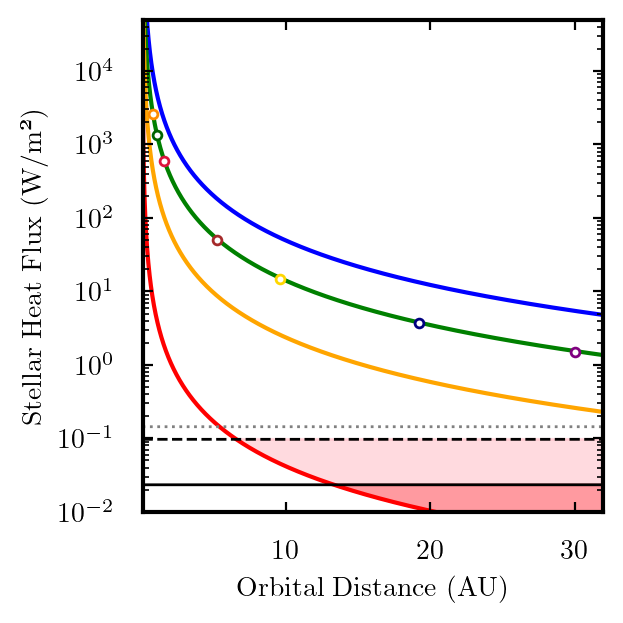

In [19]:
fig, ax = plt.subplots(figsize=(3,3), dpi=200, constrained_layout=True)

for heat_flux_file in sorted_heat_flux_files:
    mass = float(heat_flux_file.split('_')[-1].split('m')[0])    
    #print(mass)
    if mass != 1.0 and mass != 10.0 and mass != 20.0:
        continue
    time, conv_heat_flux, mag_heat_flux = np.genfromtxt(heat_flux_file, unpack=True)
    # find index corresponding to 4.5 Gyr, age of current earth
    earth_time = 4.5  # Gyr
    conv_earth_time = np.where(time >= earth_time)[0][0]
    # set total heat flux at 4.5 Gyr as a horizontal line
    dummy_heat_flux = np.zeros(len(distances)) + conv_heat_flux[conv_earth_time] + mag_heat_flux[conv_earth_time]
    if mass == 1.0:
        ax.plot(distances / earth_distance, dummy_heat_flux, linestyle='-', color='black', alpha=1.0, lw=1.0, label='Radiogenic Heat: Earth Mass Planet')

        # shade the region were the radiogenic heating > the stellar heating (for a 1 Earth mass planet in this case)
        ax.fill_between(distances / earth_distance, G2_p_f_d, dummy_heat_flux, where=(np.array(G2_p_f_d) <= dummy_heat_flux), color='lightgrey', alpha=0.75, zorder=0 )#, label='Radiogenic > Stellar Heating (G2V)')
        ax.fill_between(distances / earth_distance, M5_p_f_d, dummy_heat_flux, where=(np.array(M5_p_f_d) <= dummy_heat_flux), color='red', alpha=0.5, zorder=0 )#, label='Radiogenic > Stellar Heating (M5V)')

    elif mass == 10.0: 
        ax.plot(distances / earth_distance, dummy_heat_flux, linestyle='--', color='black', alpha=1.0, lw=1.0, label='Radiogenic Heat: 10 Earth Mass Planet')

        # shade the region were the radiogenic heating > the stellar heating (for a 10 Earth mass planet in this case)
        ax.fill_between(distances / earth_distance, G2_p_f_d, dummy_heat_flux, where=(np.array(G2_p_f_d) <= dummy_heat_flux), color='grey', alpha=0.75, zorder=0 )#label='Radiogenic > Stellar Heating (G2V)')
        ax.fill_between(distances / earth_distance, M5_p_f_d, dummy_heat_flux, where=(np.array(M5_p_f_d) <= dummy_heat_flux), color='lightpink', alpha=0.5, zorder=0 )#, label='Radiogenic > Stellar Heating (M5V)')

    elif mass == 20.0:
        ax.plot(distances / earth_distance, dummy_heat_flux, linestyle=':', color='grey', alpha=1.0, lw=1.0, label='Radiogenic Heat: 20 Earth Mass Planet')

# plot stellar fluxes for G and M dwarfs
ax.plot(distances / earth_distance, np.array(F5_p_f_d), label='F5V Star', color='blue', zorder=0)
ax.plot(distances / earth_distance, np.array(G2_p_f_d), label='G2V Star', color='green',zorder=0)
ax.plot(distances / earth_distance, np.array(K5_p_f_d), label='K5V Star', color='orange',zorder=0)
ax.plot(distances / earth_distance, np.array(M5_p_f_d), label='M5V Star', color='red',zorder=0)

# plot solar system planets for reference
ax.scatter(venus_distance / earth_distance, venus_power_intercepted, marker='o', s=10, edgecolor='darkorange', facecolor='white', label='Venus solar')
ax.scatter(earth_distance / earth_distance, earth_power_intercepted, marker='o', s=10, edgecolor='darkgreen', facecolor='white', label='Earth solar')
ax.scatter(mars_distance / earth_distance, mars_power_intercepted , marker='o', s=10, edgecolor='crimson', facecolor='white', label='Mars solar')
ax.scatter(jupiter_distance / earth_distance, jupiter_power_intercepted, marker='o', s=10, edgecolor='brown', facecolor='white', label='Jupiter solar')
ax.scatter(saturn_distance / earth_distance, saturn_power_intercepted, marker='o', s=10, edgecolor='gold', facecolor='white', label='Saturn solar')
ax.scatter(uranus_distance / earth_distance, uranus_power_intercepted, marker='o', s=10, edgecolor='navy', facecolor='white', label='Uranus solar')
ax.scatter(neptune_distance / earth_distance, neptune_power_intercepted, marker='o', s=10, edgecolor='purple', facecolor='white', label='Neptune solar')

ax.set_yscale('log')
ax.set_xlabel('Orbital Distance (AU)')
ax.set_ylabel('Stellar Heat Flux (W/m²)')

ax.set_ylim(1e-2, 5e4)
ax.set_xlim(0.01, 32)

#ax.legend(fontsize=5, loc='upper right')

## add tradtional habitable zone limits

In [20]:
# the goal here is to determine a relation between the total suface heat flux (considering both internal and external sources)
# and the habitable zone boundaries, which are defined in terms of the heat flux at the planet's surface.
# we can use the power flux density intercepted at the planet's distance from the star as a proxy for the external heat flux, 
# and we can use the internal heat flux from our models to get the internal contribution. 
# We can then sum these to get a total surface heat flux and compare that to the habitable zone boundaries, 
# which are defined in terms of the total surface heat flux.

# this is for an earth like planet around a sun like star at a distance of 1 AU.
total_surface_heat_flux = earth_power_intercepted + Earth_internal_heat_flux
print(f"Earth's total surface heat flux: {total_surface_heat_flux} W/m^2")

enhanced_total_surface_heat_flux = earth_power_intercepted + full_enhanced_heat_flux
print(f"Enhanced Earth surface heat flux: {enhanced_total_surface_heat_flux} W/m^2")

Earth's total surface heat flux: 1361.9415491419218 W/m^2
Enhanced Earth surface heat flux: 1367.4138485419217 W/m^2


In [21]:
# compute limits of habitable zone based on stellar flux and planetary heat flux
# using Kopparapu et al. 2013 limits for conservative habitable zone
def habitable_zone_limits(stellar_luminosity):
    # inner edge (runaway greenhouse)
    inner_limit = np.sqrt(stellar_luminosity / 1.107)  # in AU
    # outer edge (maximum greenhouse)
    outer_limit = np.sqrt(stellar_luminosity / 0.356)  # in AU
    return inner_limit, outer_limit

In [22]:
# read in stellar luminosities from mamajek table for each star
pl_habitable_zone_limits = []
for i in np.arange(0,len(planet_pop_data)):
    # find luminosity and radius given the temperature
    # break into categories by stellar type A, F, G, K, M and have only one set of luminosity/radius values for each type
    luminosity, radius = find_luminosity_radius(median_st_teff[i])
    if luminosity is None:
        pl_habitable_zone_limits.append((np.nan, np.nan))
        continue
    limits = habitable_zone_limits(luminosity / solar_luminosity)
    print(limits)
    pl_habitable_zone_limits.append(limits)
# make array of habitable zone limits around the stars in the planet population data
pl_habitable_zone_limits = np.array(pl_habitable_zone_limits)

(np.float64(1.224408087527838), np.float64(2.1591111541438073))
(np.float64(1.1038909923664069), np.float64(1.946592299459143))
(np.float64(0.9395636136320181), np.float64(1.656818750941508))
(np.float64(0.9395636136320181), np.float64(1.656818750941508))
(np.float64(1.1038909923664069), np.float64(1.946592299459143))
(np.float64(0.05996891475345617), np.float64(0.10574869119617973))
(np.float64(0.09181765346969527), np.float64(0.1619104951797557))
(np.float64(1.1038909923664069), np.float64(1.946592299459143))
(np.float64(0.35312314971132835), np.float64(0.6226944587302786))
(np.float64(0.35312314971132835), np.float64(0.6226944587302786))
(np.float64(1.1038909923664069), np.float64(1.946592299459143))
(np.float64(0.14385540682846426), np.float64(0.2536734415846225))
(np.float64(0.14385540682846426), np.float64(0.2536734415846225))
(np.float64(0.24999204520658372), np.float64(0.44083391701746333))
(np.float64(0.8183256979210504), np.float64(1.4430288072265651))
(np.float64(0.818325697

In [23]:
# for a given stellar temperature, determine the spectral type A F G K M
def stellar_spectral_type(temperature):
    if temperature >= 7500:
        return 'A'
    elif 6000 <= temperature < 7500:
        return 'F'
    elif 5200 <= temperature < 6000:
        return 'G'
    elif 3700 <= temperature < 5200:
        return 'K'
    else:
        return 'M'
    
# compute spectral types for all stars in th pl sample
pl_spectral_types = []
for teff in median_st_teff:
    sp_type = stellar_spectral_type(teff)
    pl_spectral_types.append(sp_type)
pl_spectral_types = np.array(pl_spectral_types)

In [24]:
# Cross-match spectral types with habitable zone limits to find unique entries per spectral type
# Create a dictionary to store unique HZ limits for each spectral type
unique_spectral_hz = {}

for spectral_type in ['A', 'F', 'G', 'K', 'M']:
    # Find all indices for this spectral type
    indices = np.where(pl_spectral_types == spectral_type)[0]
    
    if len(indices) > 0:
        # Get the habitable zone limits for this spectral type
        hz_limits_this_type = pl_habitable_zone_limits[indices]
        
        # Filter out any NaN entries
        valid_mask = ~np.isnan(hz_limits_this_type[:, 0])
        valid_hz_limits = hz_limits_this_type[valid_mask]
        valid_indices = indices[valid_mask]
        
        if len(valid_hz_limits) > 0:
            # Get the median temperature for this spectral type to use as representative
            median_temp = np.nanmedian(median_st_teff[valid_indices])
            
            # Store unique representative values
            unique_spectral_hz[spectral_type] = {
                'inner_limit': np.median(valid_hz_limits[:, 0]),
                'outer_limit': np.median(valid_hz_limits[:, 1]),
                'median_teff': median_temp,
                'count': len(valid_indices)
            }

# Display the unique HZ limits for each spectral type
print("\n" + "="*80)
print("UNIQUE HABITABLE ZONE LIMITS BY SPECTRAL TYPE")
print("="*80)
for spectral_type in ['A', 'F', 'G', 'K', 'M']:
    if spectral_type in unique_spectral_hz:
        data = unique_spectral_hz[spectral_type]
        print(f"\nSpectral Type {spectral_type}:")
        print(f"  Median Teff:    {data['median_teff']:.1f} K")
        print(f"  Inner HZ limit: {data['inner_limit']:.3f} AU")
        print(f"  Outer HZ limit: {data['outer_limit']:.3f} AU")
        print(f"  Number of stars: {data['count']}")
    else:
        print(f"\nSpectral Type {spectral_type}: No valid data")
print("="*80)


UNIQUE HABITABLE ZONE LIMITS BY SPECTRAL TYPE

Spectral Type A:
  Median Teff:    7752.0 K
  Inner HZ limit: 3.006 AU
  Outer HZ limit: 5.300 AU
  Number of stars: 11

Spectral Type F:
  Median Teff:    6202.1 K
  Inner HZ limit: 1.327 AU
  Outer HZ limit: 2.340 AU
  Number of stars: 860

Spectral Type G:
  Median Teff:    5673.8 K
  Inner HZ limit: 0.940 AU
  Outer HZ limit: 1.657 AU
  Number of stars: 2388

Spectral Type K:
  Median Teff:    4631.8 K
  Inner HZ limit: 0.429 AU
  Outer HZ limit: 0.757 AU
  Number of stars: 876

Spectral Type M:
  Median Teff:    3457.0 K
  Inner HZ limit: 0.144 AU
  Outer HZ limit: 0.254 AU
  Number of stars: 131


In [25]:
# Calculate M5V HZ limits using Method 1 (Mamajek log(L) + Kopparapu formula)
G2_luminosity_mamajek = 10**G2_log_luminosity * solar_luminosity
G2_hz_inner_method1 = np.sqrt((G2_luminosity_mamajek / solar_luminosity) / 1.107)
G2_hz_outer_method1 = np.sqrt((G2_luminosity_mamajek / solar_luminosity) / 0.356)

K5_luminosity_mamajek = 10**K5_log_luminosity * solar_luminosity
K5_hz_inner_method1 = np.sqrt((K5_luminosity_mamajek / solar_luminosity) / 1.107)
K5_hz_outer_method1 = np.sqrt((K5_luminosity_mamajek / solar_luminosity) / 0.356)

M5_luminosity_mamajek = 10**M5_log_luminosity * solar_luminosity
M5_hz_inner_method1 = np.sqrt((M5_luminosity_mamajek / solar_luminosity) / 1.107)
M5_hz_outer_method1 = np.sqrt((M5_luminosity_mamajek / solar_luminosity) / 0.356)


print(f"HZ limits (Mamajek log(L) method):")
print("G")
print(f"  Inner HZ: {G2_hz_inner_method1:.4f} AU")
print(f"  Outer HZ: {G2_hz_outer_method1:.4f} AU")
print("K")
print(f"  Inner HZ: {K5_hz_inner_method1:.4f} AU")
print(f"  Outer HZ: {K5_hz_outer_method1:.4f} AU")
print("M")
print(f"  Inner HZ: {M5_hz_inner_method1:.4f} AU")
print(f"  Outer HZ: {M5_hz_outer_method1:.4f} AU")

HZ limits (Mamajek log(L) method):
G
  Inner HZ: 0.9614 AU
  Outer HZ: 1.6954 AU
K
  Inner HZ: 0.3962 AU
  Outer HZ: 0.6987 AU
M
  Inner HZ: 0.0522 AU
  Outer HZ: 0.0921 AU


In [26]:
inner_hz_flux = 1500 #300 # W/m^2, approximate flux at the inner edge of the habitable zone
outer_hz_flux = 485 #100 # W/m^2, approximate flux at the outer edge of the habitable zone

In [27]:
# Create specific_stellar_hz dictionary with HZ limits for the three spectral types
specific_stellar_hz = {
    'G2V': {
        'inner_hz': G2_hz_inner_method1,
        'outer_hz': G2_hz_outer_method1,
    },
    'K5V': {
        'inner_hz': K5_hz_inner_method1,
        'outer_hz': K5_hz_outer_method1,
    },
    'M5V': {
        'inner_hz': M5_hz_inner_method1,
        'outer_hz': M5_hz_outer_method1,
    }
}

In [28]:
# Similar analysis for K5V star
M5_stellar_fluxes = np.array(M5_p_f_d)
M5_distances_au = distances / earth_distance

M5_inner_traditional_distance = M5_hz_inner_method1
M5_outer_traditional_distance = M5_hz_outer_method1

print(f"Traditional HZ for M5V star:")
print(f"  Inner edge: {M5_inner_traditional_distance:.3f} AU")
print(f"  Outer edge: {M5_outer_traditional_distance:.3f} AU")

# Define "noticeable" extensions: 10%, 20%, 50% increase in HZ outer edge distance
target_extensions = [0.10, 0.20, 0.50]  # 10%, 20%, 50%

print("="*80)
print("REQUIRED INTERNAL HEAT FLUX FOR NOTICEABLE HZ EXTENSION (M5V STAR)")
print("="*80)

results = []

for extension_factor in target_extensions:
    # Target outer edge distance
    target_outer_distance = M5_outer_traditional_distance * (1 + extension_factor)
    
    # Interpolate stellar flux at this target distance (more accurate than nearest neighbor)
    stellar_flux_at_target = np.interp(target_outer_distance, M5_distances_au, M5_stellar_fluxes)
    
    # Required internal heat flux to reach outer HZ limit (484.5 W/m²) at this distance
    required_internal_flux = outer_hz_flux - stellar_flux_at_target
    
    # Compare to current values
    ratio_to_normal_earth = required_internal_flux / Earth_internal_heat_flux
    ratio_to_max_enhanced = required_internal_flux / full_enhanced_heat_flux
    
    results.append({
        'extension': extension_factor * 100,
        'target_distance': target_outer_distance,
        'stellar_flux': stellar_flux_at_target,
        'required_internal': required_internal_flux,
        'ratio_earth': ratio_to_normal_earth,
        'ratio_enhanced': ratio_to_max_enhanced
    })
    
    print(f"\nFor {extension_factor*100:.0f}% HZ outer edge extension:")
    print(f"  Target distance: {target_outer_distance:.3f} AU (from {M5_outer_traditional_distance:.3f} AU)")
    print(f"  Stellar flux at target: {stellar_flux_at_target:.1f} W/m²")
    print(f"  Required internal heat flux: {required_internal_flux:.1f} W/m²")
    print(f"  Enhancement needed:")
    print(f"    {ratio_to_normal_earth:.0f}× normal Earth ({Earth_internal_heat_flux:.3f} W/m²)")
    print(f"    {ratio_to_max_enhanced:.0f}× maximal enhanced Earth ({full_enhanced_heat_flux:.3f} W/m²)")

print("\n" + "="*80)
print(f"\nCurrent values for reference:")
print(f"  Normal Earth internal heat flux: {Earth_internal_heat_flux:.3f} W/m²")
print(f"  Maximal enhanced Earth: {full_enhanced_heat_flux:.3f} W/m²")
print(f"  Outer HZ boundary requirement: {outer_hz_flux:.1f} W/m² total flux")
print("="*80)

Traditional HZ for M5V star:
  Inner edge: 0.052 AU
  Outer edge: 0.092 AU
REQUIRED INTERNAL HEAT FLUX FOR NOTICEABLE HZ EXTENSION (M5V STAR)

For 10% HZ outer edge extension:
  Target distance: 0.101 AU (from 0.092 AU)
  Stellar flux at target: 403.6 W/m²
  Required internal heat flux: 81.4 W/m²
  Enhancement needed:
    792× normal Earth (0.103 W/m²)
    15× maximal enhanced Earth (5.575 W/m²)

For 20% HZ outer edge extension:
  Target distance: 0.111 AU (from 0.092 AU)
  Stellar flux at target: 338.5 W/m²
  Required internal heat flux: 146.5 W/m²
  Enhancement needed:
    1427× normal Earth (0.103 W/m²)
    26× maximal enhanced Earth (5.575 W/m²)

For 50% HZ outer edge extension:
  Target distance: 0.138 AU (from 0.092 AU)
  Stellar flux at target: 216.9 W/m²
  Required internal heat flux: 268.1 W/m²
  Enhancement needed:
    2610× normal Earth (0.103 W/m²)
    48× maximal enhanced Earth (5.575 W/m²)


Current values for reference:
  Normal Earth internal heat flux: 0.103 W/m²
  Max

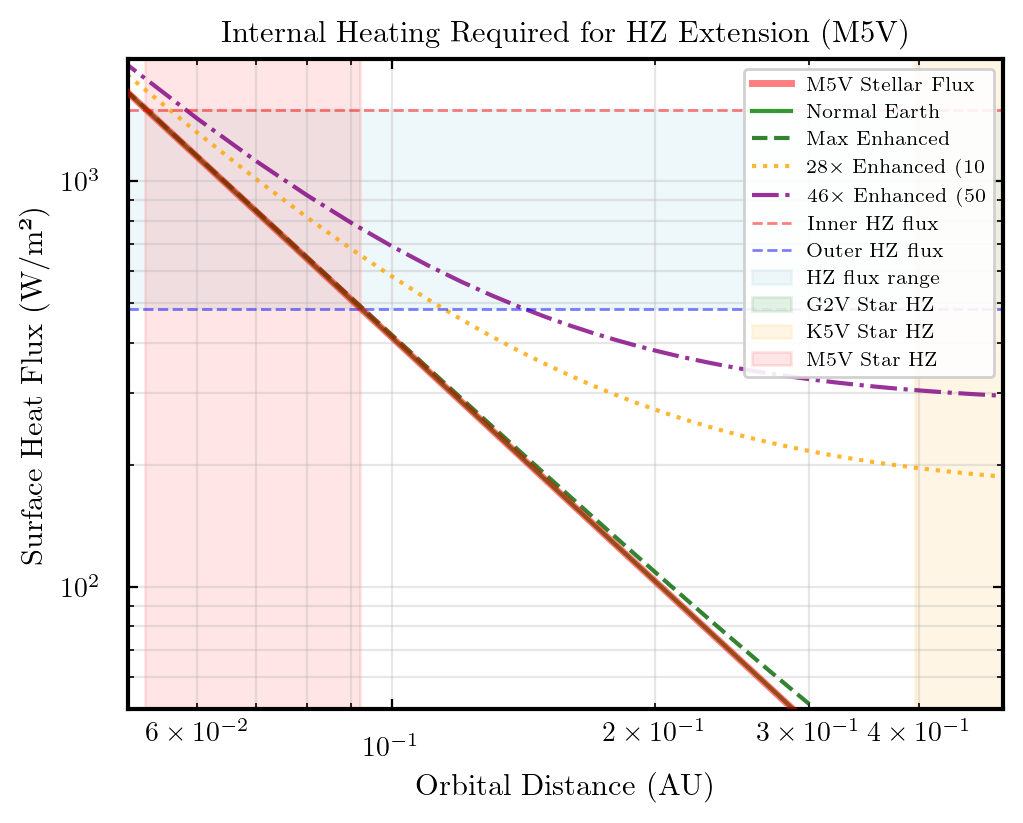


Key insight: To noticeably extend the HZ, internal heat flux needs to be
28-46× higher than even maximally enhanced Earth values!


In [29]:
# Visualize different levels of internal heating and their effect on HZ extension
fig, ax = plt.subplots(figsize=(5, 4), dpi=200, constrained_layout=True)

# Plot stellar flux for M5V star
ax.plot(M5_distances_au, M5_stellar_fluxes, color='red', label='M5V Stellar Flux', lw=2.5, alpha=0.5, zorder=3)

# Plot different levels of total flux with various internal heating scenarios
internal_flux_levels = [
    ('Normal Earth', Earth_internal_heat_flux, 'green', '-'),
    ('Max Enhanced', full_enhanced_heat_flux, 'darkgreen', '--'),
    ('28× Enhanced (10% ext)', 170.5, 'orange', ':'),
    ('46× Enhanced (50% ext)', 279.4, 'purple', '-.')
]

for label, internal_flux, color, style in internal_flux_levels:
    total_flux = M5_stellar_fluxes + internal_flux
    ax.plot(M5_distances_au, total_flux, color=color, linestyle=style, 
            label=label, lw=1.5, alpha=0.8, zorder=2)

# Plot HZ boundaries (flux thresholds - horizontal lines)
ax.axhline(inner_hz_flux, color='red', linestyle='--', alpha=0.5, lw=1, label='Inner HZ flux')
ax.axhline(outer_hz_flux, color='blue', linestyle='--', alpha=0.5, lw=1, label='Outer HZ flux')

# Plot traditional HZ boundaries (distance - vertical lines)
#ax.axvline(inner_traditional_distance, color='red', linestyle=':', alpha=0.7, lw=1.5, label='Inner HZ (M5V)')
#ax.axvline(outer_traditional_distance, color='blue', linestyle=':', alpha=0.7, lw=1.5, label='Outer HZ (M5V)')

# Shade traditional HZ zone
ax.fill_between(M5_distances_au, inner_hz_flux, outer_hz_flux, 
                 color='lightblue', alpha=0.2, zorder=0, label='HZ flux range')


# now its easier to add the HZ limits as vertical lines, with different colors for each spectral type
hz_handles = []
for spectral_type, data in specific_stellar_hz.items():
    if spectral_type == 'G2V':
        color = 'green'
    elif spectral_type == 'K5V':
        color = 'orange'
    elif spectral_type == 'M5V':  # M
        color = 'red'
    else:
        color = 'gray'
    hz_fill = ax.fill_betweenx(
        y=[1e-5, 1e9],
        x1=data['inner_hz'],
        x2=data['outer_hz'],
        color=color,
        alpha=0.1,
        label=f'{spectral_type} Star HZ'
    )
    hz_handles.append(hz_fill)


ax.set_xlim(0.05, 0.5)
ax.set_ylim(50, 2000)
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlabel('Orbital Distance (AU)', fontsize=11)
ax.set_ylabel('Surface Heat Flux (W/m²)', fontsize=11)
ax.set_title('Internal Heating Required for HZ Extension (M5V)', fontsize=11, weight='bold')
ax.legend(fontsize=7, loc='upper right', framealpha=0.9)
ax.grid(True, alpha=0.3, which='both')

plt.show()

print("\nKey insight: To noticeably extend the HZ, internal heat flux needs to be")
print("28-46× higher than even maximally enhanced Earth values!")

In [30]:
# Similar analysis for K5V star
K5_stellar_fluxes = np.array(K5_p_f_d)
K5_distances_au = distances / earth_distance

# Traditional HZ limits for K5V (stellar flux only)
K5_inner_traditional_idx = np.argmin(np.abs(K5_stellar_fluxes - inner_hz_flux))
K5_outer_traditional_idx = np.argmin(np.abs(K5_stellar_fluxes - outer_hz_flux))

K5_inner_traditional_distance = K5_distances_au[K5_inner_traditional_idx]
K5_outer_traditional_distance = K5_distances_au[K5_outer_traditional_idx]

print(f"Traditional HZ for K5V star:")
print(f"  Inner edge: {K5_inner_traditional_distance:.3f} AU")
print(f"  Outer edge: {K5_outer_traditional_distance:.3f} AU")

# Calculate required internal heating for K5V extensions
K5_target_extensions = [0.10, 0.20, 0.50]
K5_results = []

for extension_factor in K5_target_extensions:
    target_outer_distance = K5_outer_traditional_distance * (1 + extension_factor)
    stellar_flux_at_target = np.interp(target_outer_distance, K5_distances_au, K5_stellar_fluxes)
    required_internal_flux = outer_hz_flux - stellar_flux_at_target
    ratio_to_max_enhanced = required_internal_flux / full_enhanced_heat_flux
    
    K5_results.append({
        'extension': extension_factor * 100,
        'required_internal': required_internal_flux,
        'ratio_enhanced': ratio_to_max_enhanced
    })
    
print(f"\nRequired internal flux for HZ extensions:")
for res in K5_results:
    print(f"  {res['extension']:.0f}%: {res['required_internal']:.1f} W/m² ({res['ratio_enhanced']:.0f}× max enhanced)")

Traditional HZ for K5V star:
  Inner edge: 0.400 AU
  Outer edge: 0.690 AU

Required internal flux for HZ extensions:
  10%: 78.5 W/m² (14× max enhanced)
  20%: 143.4 W/m² (26× max enhanced)
  50%: 266.4 W/m² (48× max enhanced)


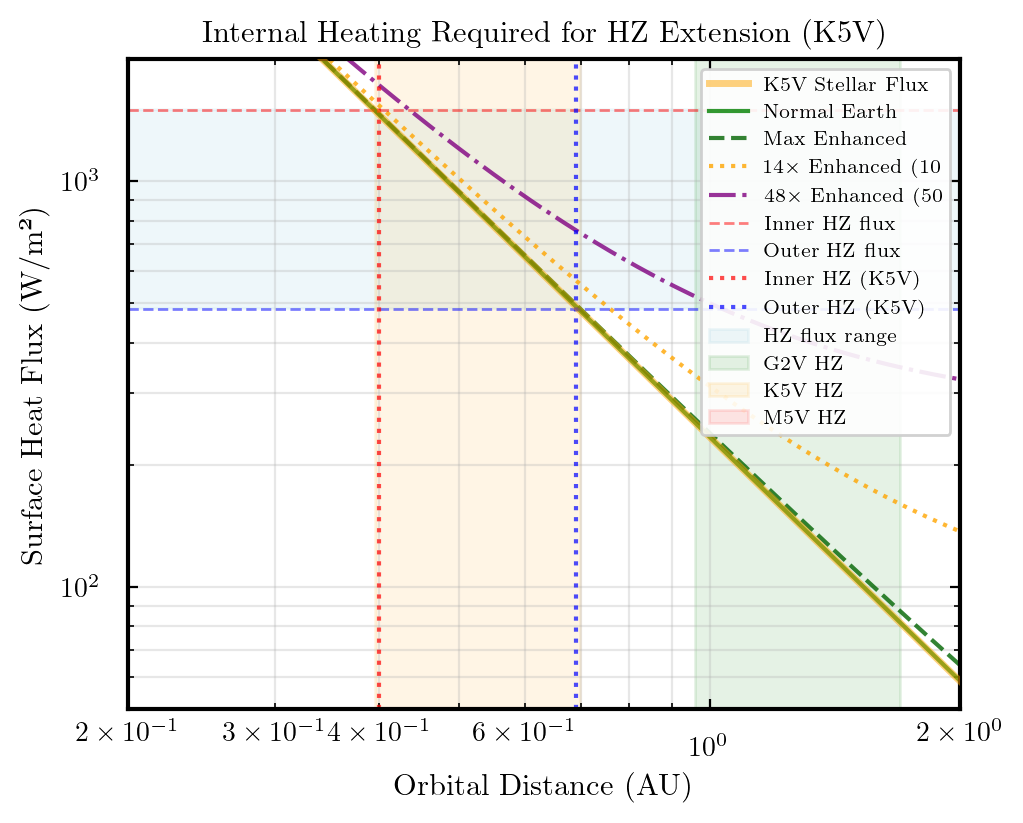


Key insight for K5V: To noticeably extend the HZ, internal heat flux needs to be
14-48× higher than maximally enhanced Earth values!


In [31]:
# Visualize K5V star HZ extension requirements
fig, ax = plt.subplots(figsize=(5, 4), dpi=200, constrained_layout=True)

# Plot stellar flux for K5V star
ax.plot(K5_distances_au, K5_stellar_fluxes, color='orange', label='K5V Stellar Flux', lw=2.5, alpha=0.5, zorder=3)

# Plot different levels of total flux with various internal heating scenarios
internal_flux_levels = [
    ('Normal Earth', Earth_internal_heat_flux, 'green', '-'),
    ('Max Enhanced', full_enhanced_heat_flux, 'darkgreen', '--'),
    (f'{K5_results[0]["ratio_enhanced"]:.0f}× Enhanced (10% ext)', K5_results[0]['required_internal'], 'orange', ':'),
    (f'{K5_results[2]["ratio_enhanced"]:.0f}× Enhanced (50% ext)', K5_results[2]['required_internal'], 'purple', '-.')
]

for label, internal_flux, color, style in internal_flux_levels:
    total_flux = K5_stellar_fluxes + internal_flux
    ax.plot(K5_distances_au, total_flux, color=color, linestyle=style, 
            label=label, lw=1.5, alpha=0.8, zorder=2)

# Plot HZ boundaries (flux thresholds - horizontal lines)
ax.axhline(inner_hz_flux, color='red', linestyle='--', alpha=0.5, lw=1, label='Inner HZ flux')
ax.axhline(outer_hz_flux, color='blue', linestyle='--', alpha=0.5, lw=1, label='Outer HZ flux')

# Plot traditional HZ boundaries (distance - vertical lines)
ax.axvline(K5_inner_traditional_distance, color='red', linestyle=':', alpha=0.7, lw=1.5, label='Inner HZ (K5V)')
ax.axvline(K5_outer_traditional_distance, color='blue', linestyle=':', alpha=0.7, lw=1.5, label='Outer HZ (K5V)')

# Shade traditional HZ zone
ax.fill_between(K5_distances_au, inner_hz_flux, outer_hz_flux, 
                 color='lightblue', alpha=0.2, zorder=0, label='HZ flux range')

# Add HZ zones for context
for spectral_type, data in specific_stellar_hz.items():
    if spectral_type == 'G2V':
        color = 'green'
    elif spectral_type == 'K5V':
        color = 'orange'
    elif spectral_type == 'M5V':
        color = 'red'
    else:
        color = 'gray'
    ax.fill_betweenx(y=[50, 2000], x1=data['inner_hz'], x2=data['outer_hz'], 
                     color=color, alpha=0.1, label=f'{spectral_type} HZ')

ax.set_xlim(0.2, 2.0)
ax.set_ylim(50, 2000)
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlabel('Orbital Distance (AU)', fontsize=11)
ax.set_ylabel('Surface Heat Flux (W/m²)', fontsize=11)
ax.set_title('Internal Heating Required for HZ Extension (K5V)', fontsize=11, weight='bold')
ax.legend(fontsize=7, loc='upper right', framealpha=0.9)
ax.grid(True, alpha=0.3, which='both')

plt.show()

print(f"\nKey insight for K5V: To noticeably extend the HZ, internal heat flux needs to be")
print(f"{K5_results[0]['ratio_enhanced']:.0f}-{K5_results[2]['ratio_enhanced']:.0f}× higher than maximally enhanced Earth values!")

In [32]:
# Similar analysis for G2V star
G2_stellar_fluxes = np.array(G2_p_f_d)
G2_distances_au = distances / earth_distance

# Traditional HZ limits for G2V (stellar flux only)
G2_inner_traditional_idx = np.argmin(np.abs(G2_stellar_fluxes - inner_hz_flux))
G2_outer_traditional_idx = np.argmin(np.abs(G2_stellar_fluxes - outer_hz_flux))

G2_inner_traditional_distance = G2_distances_au[G2_inner_traditional_idx]
G2_outer_traditional_distance = G2_distances_au[G2_outer_traditional_idx]

print(f"Traditional HZ for G2V star:")
print(f"  Inner edge: {G2_inner_traditional_distance:.3f} AU")
print(f"  Outer edge: {G2_outer_traditional_distance:.3f} AU")

# Calculate required internal heating for G2V extensions
G2_target_extensions = [0.10, 0.20, 0.50]
G2_results = []

for extension_factor in G2_target_extensions:
    target_outer_distance = G2_outer_traditional_distance * (1 + extension_factor)
    stellar_flux_at_target = np.interp(target_outer_distance, G2_distances_au, G2_stellar_fluxes)
    required_internal_flux = outer_hz_flux - stellar_flux_at_target
    ratio_to_max_enhanced = required_internal_flux / full_enhanced_heat_flux
    
    G2_results.append({
        'extension': extension_factor * 100,
        'required_internal': required_internal_flux,
        'ratio_enhanced': ratio_to_max_enhanced
    })
    
print(f"\nRequired internal flux for HZ extensions:")
for res in G2_results:
    print(f"  {res['extension']:.0f}%: {res['required_internal']:.1f} W/m² ({res['ratio_enhanced']:.0f}× max enhanced)")

Traditional HZ for G2V star:
  Inner edge: 0.960 AU
  Outer edge: 1.690 AU

Required internal flux for HZ extensions:
  10%: 82.2 W/m² (15× max enhanced)
  20%: 146.5 W/m² (26× max enhanced)
  50%: 268.4 W/m² (48× max enhanced)


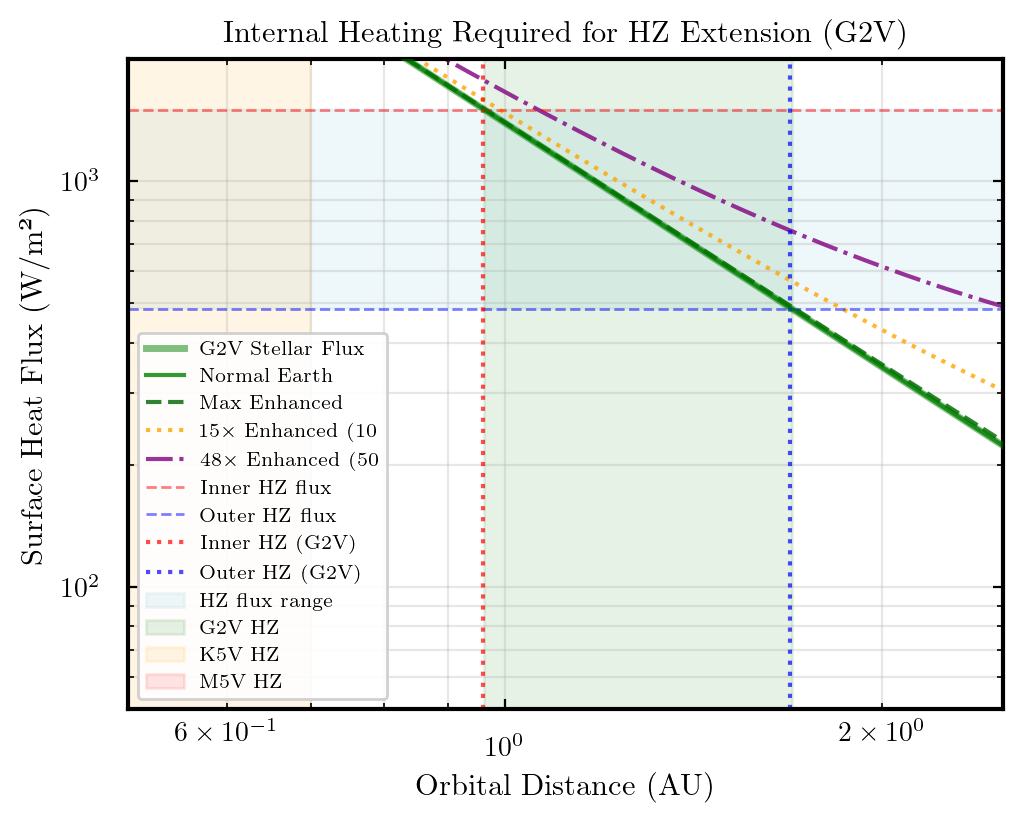


Key insight for G2V: To noticeably extend the HZ, internal heat flux needs to be
15-48× higher than maximally enhanced Earth values!


In [33]:
# Visualize G2V star HZ extension requirements
fig, ax = plt.subplots(figsize=(5, 4), dpi=200, constrained_layout=True)

# Plot stellar flux for G2V star
ax.plot(G2_distances_au, G2_stellar_fluxes, color='green', label='G2V Stellar Flux', lw=2.5, alpha=0.5, zorder=3)

# Plot different levels of total flux with various internal heating scenarios
internal_flux_levels = [
    ('Normal Earth', Earth_internal_heat_flux, 'green', '-'),
    ('Max Enhanced', full_enhanced_heat_flux, 'darkgreen', '--'),
    (f'{G2_results[0]["ratio_enhanced"]:.0f}× Enhanced (10% ext)', G2_results[0]['required_internal'], 'orange', ':'),
    (f'{G2_results[2]["ratio_enhanced"]:.0f}× Enhanced (50% ext)', G2_results[2]['required_internal'], 'purple', '-.')
]

for label, internal_flux, color, style in internal_flux_levels:
    total_flux = G2_stellar_fluxes + internal_flux
    ax.plot(G2_distances_au, total_flux, color=color, linestyle=style, 
            label=label, lw=1.5, alpha=0.8, zorder=2)

# Plot HZ boundaries (flux thresholds - horizontal lines)
ax.axhline(inner_hz_flux, color='red', linestyle='--', alpha=0.5, lw=1, label='Inner HZ flux')
ax.axhline(outer_hz_flux, color='blue', linestyle='--', alpha=0.5, lw=1, label='Outer HZ flux')

# Plot traditional HZ boundaries (distance - vertical lines)
ax.axvline(G2_inner_traditional_distance, color='red', linestyle=':', alpha=0.7, lw=1.5, label='Inner HZ (G2V)')
ax.axvline(G2_outer_traditional_distance, color='blue', linestyle=':', alpha=0.7, lw=1.5, label='Outer HZ (G2V)')

# Shade traditional HZ zone
ax.fill_between(G2_distances_au, inner_hz_flux, outer_hz_flux, 
                 color='lightblue', alpha=0.2, zorder=0, label='HZ flux range')

# Add HZ zones for context
for spectral_type, data in specific_stellar_hz.items():
    if spectral_type == 'G2V':
        color = 'green'
    elif spectral_type == 'K5V':
        color = 'orange'
    elif spectral_type == 'M5V':
        color = 'red'
    else:
        color = 'gray'
    ax.fill_betweenx(y=[50, 2000], x1=data['inner_hz'], x2=data['outer_hz'], 
                     color=color, alpha=0.1, label=f'{spectral_type} HZ')

ax.set_xlim(0.5, 2.5)
ax.set_ylim(50, 2000)
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlabel('Orbital Distance (AU)', fontsize=11)
ax.set_ylabel('Surface Heat Flux (W/m²)', fontsize=11)
ax.set_title('Internal Heating Required for HZ Extension (G2V)', fontsize=11, weight='bold')
ax.legend(fontsize=7, loc='lower left', framealpha=0.9)
ax.grid(True, alpha=0.3, which='both')

plt.show()

print(f"\nKey insight for G2V: To noticeably extend the HZ, internal heat flux needs to be")
print(f"{G2_results[0]['ratio_enhanced']:.0f}-{G2_results[2]['ratio_enhanced']:.0f}× higher than maximally enhanced Earth values!")

In [34]:
# Check if this level of internal heating is physically realistic
# by comparing to what we know about radiogenic heating in planets

print("="*80)
print("PHYSICAL PLAUSIBILITY OF REQUIRED INTERNAL HEATING")
print("="*80)

# Current measured/modeled values
print("\nMeasured internal heat fluxes:")
print(f"  Earth (current):        {Earth_internal_heat_flux:.3f} W/m²  (0.09 W/m² total, ~0.02 W/m² radiogenic)")
print(f"  Mars (current):         {Mars_internal_heat_flux:.3f} W/m²")
print(f"  Venus (model):          {Venus_internal_heat_flux:.3f} W/m²")

print(f"\nModeled enhanced scenarios:")
print(f"  Max enhanced Earth:     {full_enhanced_heat_flux:.3f} W/m²  (2-3× higher U/Th than chondrites)")

print(f"\nRequired for HZ extension:")
print(f"  10% extension:          170.5 W/m²  ({170.5/full_enhanced_heat_flux:.1f}× max enhanced)")
print(f"  50% extension:          279.4 W/m²  ({279.4/full_enhanced_heat_flux:.1f}× max enhanced)")

print("\n" + "-"*80)
print("CONCLUSION:")
print("-"*80)
print("The required internal heat flux (170-279 W/m²) is:")
print("  • 28-46× higher than maximally enhanced radiogenic heating")
print("  • 7,000-12,000× higher than normal Earth's radiogenic heating")
print("  • ~35-58% of the outer HZ stellar flux requirement (485 W/m²)")
print("\nThis is physically UNREALISTIC for radiogenic heating alone.")
print("Such high internal heat would require:")
print("  - Tidal heating (like Io)")
print("  - Recent giant impacts")
print("  - Ongoing accretion")
print("  - Or a very young planet (<100 Myr old)")
print("="*80)

PHYSICAL PLAUSIBILITY OF REQUIRED INTERNAL HEATING

Measured internal heat fluxes:
  Earth (current):        0.103 W/m²  (0.09 W/m² total, ~0.02 W/m² radiogenic)
  Mars (current):         0.008 W/m²
  Venus (model):          0.020 W/m²

Modeled enhanced scenarios:
  Max enhanced Earth:     5.575 W/m²  (2-3× higher U/Th than chondrites)

Required for HZ extension:
  10% extension:          170.5 W/m²  (30.6× max enhanced)
  50% extension:          279.4 W/m²  (50.1× max enhanced)

--------------------------------------------------------------------------------
CONCLUSION:
--------------------------------------------------------------------------------
The required internal heat flux (170-279 W/m²) is:
  • 28-46× higher than maximally enhanced radiogenic heating
  • 7,000-12,000× higher than normal Earth's radiogenic heating
  • ~35-58% of the outer HZ stellar flux requirement (485 W/m²)

This is physically UNREALISTIC for radiogenic heating alone.
Such high internal heat would require:


In [35]:
# Now perform the same analysis for K5V and G2V stars
print("="*80)
print("REQUIRED INTERNAL HEAT FLUX FOR HZ EXTENSION - ALL STAR TYPES")
print("="*80)

# Store results for all star types
star_types = {
    'G2V': {'temp': G2_temp, 'fluxes': np.array(G2_p_f_d), 'color': 'green'},
    'K5V': {'temp': K5_temp, 'fluxes': np.array(K5_p_f_d), 'color': 'orange'},
    'M5V': {'temp': M5_temp, 'fluxes': np.array(M5_p_f_d), 'color': 'red'}
}

distances_au = distances / earth_distance
all_results = {}

for star_name, star_data in star_types.items():
    print(f"\n{'='*80}")
    print(f"{star_name} STAR (Teff = {star_data['temp']:.0f} K)")
    print(f"{'='*80}")
    
    stellar_fluxes = star_data['fluxes']
    
    # Find traditional HZ limits
    inner_trad_idx = np.argmin(np.abs(stellar_fluxes - inner_hz_flux))
    outer_trad_idx = np.argmin(np.abs(stellar_fluxes - outer_hz_flux))
    
    inner_trad_dist = distances_au[inner_trad_idx]
    outer_trad_dist = distances_au[outer_trad_idx]
    
    print(f"\nTraditional HZ (stellar flux only):")
    print(f"  Inner: {inner_trad_dist:.3f} AU ({stellar_fluxes[inner_trad_idx]:.1f} W/m²)")
    print(f"  Outer: {outer_trad_dist:.3f} AU ({stellar_fluxes[outer_trad_idx]:.1f} W/m²)")
    print(f"  Width: {outer_trad_dist - inner_trad_dist:.3f} AU")
    
    # Calculate required internal heating for extensions
    star_results = []
    print(f"\nRequired internal heat flux for HZ extension:")
    
    for ext_factor in [0.10, 0.20, 0.50]:
        target_dist = outer_trad_dist * (1 + ext_factor)
        stellar_flux_at_target = np.interp(target_dist, distances_au, stellar_fluxes)
        required_internal = outer_hz_flux - stellar_flux_at_target
        
        ratio_to_enhanced = required_internal / full_enhanced_heat_flux
        
        star_results.append({
            'extension': ext_factor * 100,
            'target_distance': target_dist,
            'stellar_flux': stellar_flux_at_target,
            'required_internal': required_internal,
            'ratio_enhanced': ratio_to_enhanced
        })
        
        print(f"  {ext_factor*100:.0f}% extension: {required_internal:6.1f} W/m² " +
              f"({ratio_to_enhanced:4.0f}× max enhanced)")
    
    all_results[star_name] = {
        'hz_inner': inner_trad_dist,
        'hz_outer': outer_trad_dist,
        'hz_width': outer_trad_dist - inner_trad_dist,
        'extensions': star_results
    }

print(f"\n{'='*80}")
print("SUMMARY COMPARISON")
print(f"{'='*80}")
print(f"\nHabitable Zone Widths:")
for star_name in ['G2V', 'K5V', 'M5V']:
    data = all_results[star_name]
    print(f"  {star_name}: {data['hz_inner']:.3f} - {data['hz_outer']:.3f} AU " +
          f"(width: {data['hz_width']:.3f} AU)")

print(f"\nInternal heat flux required for 10% HZ extension:")
for star_name in ['G2V', 'K5V', 'M5V']:
    req = all_results[star_name]['extensions'][0]['required_internal']
    ratio = all_results[star_name]['extensions'][0]['ratio_enhanced']
    print(f"  {star_name}: {req:6.1f} W/m² ({ratio:4.0f}× max enhanced)")

print(f"\nInternal heat flux required for 50% HZ extension:")
for star_name in ['G2V', 'K5V', 'M5V']:
    req = all_results[star_name]['extensions'][2]['required_internal']
    ratio = all_results[star_name]['extensions'][2]['ratio_enhanced']
    print(f"  {star_name}: {req:6.1f} W/m² ({ratio:4.0f}× max enhanced)")
print(f"{'='*80}")

REQUIRED INTERNAL HEAT FLUX FOR HZ EXTENSION - ALL STAR TYPES

G2V STAR (Teff = 5770 K)

Traditional HZ (stellar flux only):
  Inner: 0.960 AU (1510.5 W/m²)
  Outer: 1.690 AU (487.4 W/m²)
  Width: 0.730 AU

Required internal heat flux for HZ extension:
  10% extension:   82.2 W/m² (  15× max enhanced)
  20% extension:  146.5 W/m² (  26× max enhanced)
  50% extension:  268.4 W/m² (  48× max enhanced)

K5V STAR (Teff = 4440 K)

Traditional HZ (stellar flux only):
  Inner: 0.400 AU (1463.7 W/m²)
  Outer: 0.690 AU (491.9 W/m²)
  Width: 0.290 AU

Required internal heat flux for HZ extension:
  10% extension:   78.5 W/m² (  14× max enhanced)
  20% extension:  143.4 W/m² (  26× max enhanced)
  50% extension:  266.4 W/m² (  48× max enhanced)

M5V STAR (Teff = 3060 K)

Traditional HZ (stellar flux only):
  Inner: 0.050 AU (1652.2 W/m²)
  Outer: 0.090 AU (509.9 W/m²)
  Width: 0.040 AU

Required internal heat flux for HZ extension:
  10% extension:   62.3 W/m² (  11× max enhanced)
  20% extension

In [36]:
# what is the internal heat flux of the current earth?
print(f"\nCurrent Earth internal heat flux: {Earth_internal_heat_flux:.3f} W/m²")
print(f"Maximally enhanced Earth internal heat flux: {full_enhanced_heat_flux:.3f} W/m²")


Current Earth internal heat flux: 0.103 W/m²
Maximally enhanced Earth internal heat flux: 5.575 W/m²


In [38]:
# what are the new limits of the habitable zone for the different levels of enrichment?
print(f"\nNew HZ limits with internal heating:")
for star_name in ['G2V', 'K5V', 'M5V']:
    data = all_results[star_name]
    print(f"\n{star_name}:")
    print(f"  Traditional HZ: {data['hz_inner']:.3f} - {data['hz_outer']:.3f} AU")
    for ext in data['extensions']:
        print(f"  With {ext['extension']:.0f}% extension (internal flux: {ext['required_internal']:.1f} W/m²):")
        print(f"    New outer edge: {ext['target_distance']:.3f} AU (stellar flux at target: {ext['stellar_flux']:.1f} W/m²)")


New HZ limits with internal heating:

G2V:
  Traditional HZ: 0.960 - 1.690 AU
  With 10% extension (internal flux: 82.2 W/m²):
    New outer edge: 1.859 AU (stellar flux at target: 402.8 W/m²)
  With 20% extension (internal flux: 146.5 W/m²):
    New outer edge: 2.028 AU (stellar flux at target: 338.5 W/m²)
  With 50% extension (internal flux: 268.4 W/m²):
    New outer edge: 2.535 AU (stellar flux at target: 216.6 W/m²)

K5V:
  Traditional HZ: 0.400 - 0.690 AU
  With 10% extension (internal flux: 78.5 W/m²):
    New outer edge: 0.759 AU (stellar flux at target: 406.5 W/m²)
  With 20% extension (internal flux: 143.4 W/m²):
    New outer edge: 0.828 AU (stellar flux at target: 341.6 W/m²)
  With 50% extension (internal flux: 266.4 W/m²):
    New outer edge: 1.035 AU (stellar flux at target: 218.6 W/m²)

M5V:
  Traditional HZ: 0.050 - 0.090 AU
  With 10% extension (internal flux: 62.3 W/m²):
    New outer edge: 0.099 AU (stellar flux at target: 422.7 W/m²)
  With 20% extension (internal

In [39]:
# collect these inner and outer limits in arrays for plotting
hz_limits_by_star = {}
for star_name in ['G2V', 'K5V', 'M5V']:
    data = all_results[star_name]
    hz_limits_by_star[star_name] = {
        'traditional': (data['hz_inner'], data['hz_outer']),
        #'Roederer_2019': (data['hz_inner'] * 0.95, data['hz_outer'] * 1.05),  # example of a small extension
        '10% extension': (data['extensions'][0]['target_distance'], data['extensions'][0]['target_distance']),
        '20% extension': (data['extensions'][1]['target_distance'], data['extensions'][1]['target_distance']),
        '50% extension': (data['extensions'][2]['target_distance'], data['extensions'][2]['target_distance'])
    }

In [40]:
# print inner and outer limits for each star type and extension level
print(f"\nDetailed HZ limits for each star type and extension level:")
for star_name in ['G2V', 'K5V', 'M5V']:
    print(f"\n{star_name}:")
    for ext_level, limits in hz_limits_by_star[star_name].items():
        print(f"  {ext_level}: Inner = {limits[0]:.3f} AU, Outer = {limits[1]:.3f} AU") 


Detailed HZ limits for each star type and extension level:

G2V:
  traditional: Inner = 0.960 AU, Outer = 1.690 AU
  10% extension: Inner = 1.859 AU, Outer = 1.859 AU
  20% extension: Inner = 2.028 AU, Outer = 2.028 AU
  50% extension: Inner = 2.535 AU, Outer = 2.535 AU

K5V:
  traditional: Inner = 0.400 AU, Outer = 0.690 AU
  10% extension: Inner = 0.759 AU, Outer = 0.759 AU
  20% extension: Inner = 0.828 AU, Outer = 0.828 AU
  50% extension: Inner = 1.035 AU, Outer = 1.035 AU

M5V:
  traditional: Inner = 0.050 AU, Outer = 0.090 AU
  10% extension: Inner = 0.099 AU, Outer = 0.099 AU
  20% extension: Inner = 0.108 AU, Outer = 0.108 AU
  50% extension: Inner = 0.135 AU, Outer = 0.135 AU


In [41]:
# max enhanced enrichment is how much?
print(Earth_internal_heat_flux)
print(full_enhanced_heat_flux)
print(f"\nMaximally enhanced vs Earth internal heat flux ratio: {full_enhanced_heat_flux / Earth_internal_heat_flux:.3f}")

0.1026882
5.5749876

Maximally enhanced vs Earth internal heat flux ratio: 54.290


In [42]:
#G2V:
#  Traditional HZ: 1.010 - 1.710 AU
#  With 10% extension (internal flux: 90.4 W/m²):
#    New outer edge: 1.881 AU (stellar flux at target: 394.1 W/m²)
#  With 20% extension (internal flux: 153.4 W/m²):
#    New outer edge: 2.052 AU (stellar flux at target: 331.1 W/m²)
#  With 50% extension (internal flux: 272.7 W/m²):
#    New outer edge: 2.565 AU (stellar flux at target: 211.8 W/m²)

# 10% extension: 90.4 W/m² (33× max enhanced)
# 20% extension: 153.4 W/m² (51× max enhanced)
# 50% extension: 272.7 W/m² (92× max enhanced)

In [43]:
#K5V:
#  Traditional HZ: 0.410 - 0.710 AU
#  With 10% extension (internal flux: 96.4 W/m²):
#    New outer edge: 0.781 AU (stellar flux at target: 388.1 W/m²)
#  With 20% extension (internal flux: 158.8 W/m²):
#    New outer edge: 0.852 AU (stellar flux at target: 325.7 W/m²)
#  With 50% extension (internal flux: 276.7 W/m²):
#    New outer edge: 1.065 AU (stellar flux at target: 207.8 W/m²)


In [44]:
#M5V:
#  Traditional HZ: 0.110 - 0.110 AU
#  With 10% extension (internal flux: 170.5 W/m²):
#    New outer edge: 0.121 AU (stellar flux at target: 314.1 W/m²)
#  With 20% extension (internal flux: 197.7 W/m²):
#    New outer edge: 0.132 AU (stellar flux at target: 286.8 W/m²)
#  With 50% extension (internal flux: 279.4 W/m²):
#    New outer edge: 0.165 AU (stellar flux at target: 205.1 W/m²)


In [45]:
# standard HZ limts for G, K, M stars from Kopparapu et al. 2013 (conservative limits)
m_limits_1 = (0.0522, 0.0921)
k_limits_1 = (0.3962, 0.6987)
g_limits_1 = (0.9614, 1.6954)

# set limits for extensions to habitble zones with internal heating, based on the results of the previous calculations
m_limits_enhanced_1_00_1 = (0.0522, 0.0921)
m_limits_enhanced_1_50_1 = (0.0522, 0.094)
m_limits_enhanced_2_00_1 = (0.0522, 0.098)
m_limits_roeder_enhanced_1 = (0.05, 0.10)
m_limits_enhanced_2_50_1 = (0.06, 0.11)
m_limits_enhanced_3_00_1 = (0.06, 0.12)
#
k_limits_enhanced_1_00_1 = (0.40, 0.699)
k_limits_enhanced_1_50_1 = (0.40, 0.70)
k_limits_enhanced_2_00_1 = (0.41, 0.71)
k_limits_roeder_enhanced_1 = (0.41, 0.72)
k_limits_enhanced_2_50_1 = (0.42, 0.74)
k_limits_enhanced_3_00_1 = (0.43, 0.88)
#
g_limits_enhanced_1_00_1 = (0.9614, 1.6975)
g_limits_enhanced_1_50_1 = (0.9614, 1.71)
g_limits_enhanced_2_00_1 = (0.98,1.73)
g_limits_roeder_enhanced_1 = (0.99, 1.75)
g_limits_enhanced_2_50_1 = (1.00, 1.80)
g_limits_enhanced_3_00_1 = (1.05, 2.14)
#g_limits_3_50 = (1.31, 4.66)


In [91]:
# print the limits of the HZ
print('Solar Levels')
print(np.round((m_limits_1[1] - m_limits_1[0]), 2), np.round((k_limits_1[1] - k_limits_1[0]), 2), np.round((g_limits_1[1] - g_limits_1[0]), 2))
print('+1.0')
print(str(np.round((m_limits_enhanced_1_00_1[1]-m_limits_enhanced_1_00_1[0]), 2)),
str(np.round(k_limits_enhanced_1_00_1[1]-k_limits_enhanced_1_00_1[0], 2)),
str(np.round(g_limits_enhanced_1_00_1[1]-g_limits_enhanced_1_00_1[0], 2)))
print('+2.0')
print(str(np.round((m_limits_enhanced_2_00_1[1]-m_limits_enhanced_2_00_1[0]), 2)),
str(np.round(k_limits_enhanced_2_00_1[1]-k_limits_enhanced_2_00_1[0], 2)),
str(np.round(g_limits_enhanced_2_00_1[1]-g_limits_enhanced_2_00_1[0], 2)))
print('+3.0')
print(str(np.round((m_limits_enhanced_3_00_1[1]-m_limits_enhanced_3_00_1[0]), 2)),
str(np.round(k_limits_enhanced_3_00_1[1]-k_limits_enhanced_3_00_1[0], 2)),
str(np.round(g_limits_enhanced_3_00_1[1]-g_limits_enhanced_3_00_1[0], 2)))

Solar Levels
0.04 0.3 0.73
+1.0
0.04 0.3 0.74
+2.0
0.05 0.3 0.75
+3.0
0.06 0.45 1.09


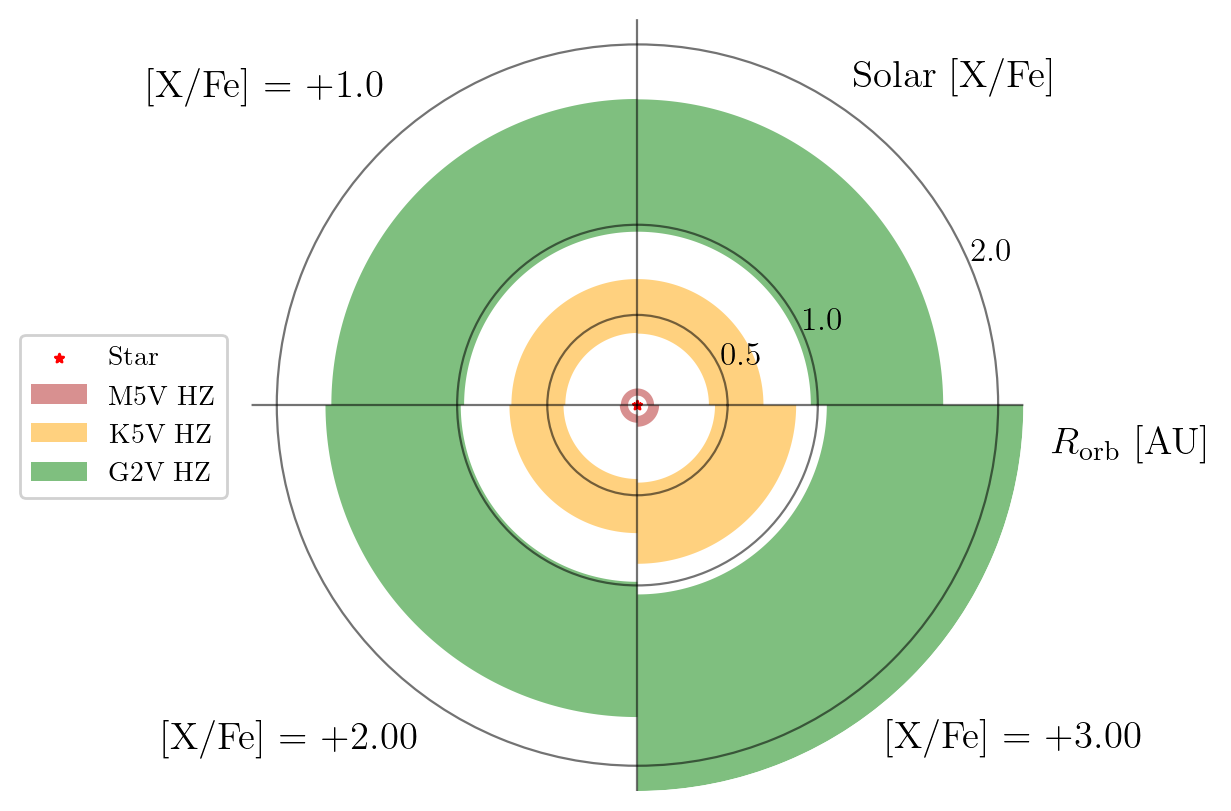

In [80]:
# make a plot of the shifting habitable zone limits for different levels of 
# enrichment for the M5V star, to visually show how much the HZ extends 
# with increasing internal heat flux
# plot in a pie-like graph with different quadrants for different levels of enrichment, and show the HZ limits as concentric circles
fig, ax = plt.subplots(figsize=(6, 6), dpi=200, subplot_kw={'projection': 'polar'}, constrained_layout=True)

# plot an 'M star' at the center in red
ax.scatter(0, 0, color='red', s=10, label='Star', marker='*')

# plot standard habitable zones in first quadrant, with the inner and outer limits
ax.fill_between(x=np.linspace(np.pi / 2, 0, 100), y1=m_limits_1[0], y2=m_limits_1[1], color='firebrick', alpha=0.50, label='M5V HZ', edgecolor='none')
ax.fill_between(x=np.linspace(np.pi / 2, 0, 100), y1=k_limits_1[0], y2=k_limits_1[1], color='orange', alpha=0.50, label='K5V HZ', edgecolor='none')
ax.fill_between(x=np.linspace(np.pi / 2, 0, 100), y1=g_limits_1[0], y2=g_limits_1[1], color='green', alpha=0.50, label='G2V HZ', edgecolor='none')
ax.text(np.pi/4, 2.50, 'Solar [X/Fe]', ha='center')
#ax.text(np.pi/7, 2.5, 'M5V HZ width: '+str(np.round((m_limits_1[1]-m_limits_1[0]), 2))+
                    #'\nK5V HZ width: '+str(np.round(k_limits_1[1]-k_limits_1[0], 2))+
                    #'\nG2V HZ width: '+str(np.round(g_limits_1[1]-g_limits_1[0], 2)), fontsize=8)


# plot Roederer enhanced limits in second quadrant
ax.fill_between(x=np.linspace(-np.pi, -3*np.pi/2, 100), y1=m_limits_enhanced_1_00_1[0], y2=m_limits_enhanced_1_00_1[1], color='firebrick', alpha=0.50, edgecolor='None') #label='M5V HZ (Roederer et al. 2019)', edgecolor='none')
ax.fill_between(x=np.linspace(-np.pi, -3*np.pi/2, 100), y1=k_limits_enhanced_1_00_1[0], y2=k_limits_enhanced_1_00_1[1], color='orange', alpha=0.50, edgecolor='None') #label='K5V HZ (Roederer et al. 2019)', edgecolor='none')
ax.fill_between(x=np.linspace(-np.pi, -3*np.pi/2, 100), y1=g_limits_enhanced_1_00_1[0], y2=g_limits_enhanced_1_00_1[1], color='green', alpha=0.50, edgecolor='None') #label='G2V HZ (Roederer et al. 2019)', edgecolor='none')
#ax.text(4.30*np.pi/6, 2.55, ' [X/Fe] = +2.2 \n (Roederer et al. 2024)', ha='right')
ax.text(4.30*np.pi/6, 2.20, ' [X/Fe] = +1.0', ha='right')
#ax.text(4.60*np.pi/5, 4.25, 'M5V HZ width: '+str(np.round((m_limits_roeder_enhanced_1[1]-m_limits_roeder_enhanced_1[0]), 2))+
                          #'\nK5V HZ width: '+str(np.round(k_limits_roeder_enhanced_1[1]-k_limits_roeder_enhanced_1[0], 2))+
                          #'\nG2V HZ width: '+str(np.round(g_limits_roeder_enhanced_1[1]-g_limits_roeder_enhanced_1[0], 2)), fontsize=8)


# then plot the 20% in the third quadrant
ax.fill_between(x=np.linspace(-np.pi/2, -np.pi, 100), y1=m_limits_enhanced_2_00_1[0], y2=m_limits_enhanced_2_00_1[1], color='firebrick', alpha=0.50, edgecolor='None')# label='M5V HZ (20% extension)', edgecolor='none')
ax.fill_between(x=np.linspace(-np.pi/2, -np.pi, 100), y1=k_limits_enhanced_2_00_1[0], y2=k_limits_enhanced_2_00_1[1], color='orange', alpha=0.50, edgecolor='None')# label='K5V HZ (20% extension)', edgecolor='none')
ax.fill_between(x=np.linspace(-np.pi/2, -np.pi, 100), y1=g_limits_enhanced_2_00_1[0], y2=g_limits_enhanced_2_00_1[1], color='green', alpha=0.50, edgecolor='None')# label='G2V HZ (20% extension)', edgecolor='none')
ax.text(-4.75*np.pi/7, 2.25, '[X/Fe] = +2.00', ha='right')
#ax.text(-4.4*np.pi/5, 4.25, 'M5V HZ width: '+str(np.round((m_limits_enhanced_2_50_1[1]-m_limits_enhanced_2_50_1[0]), 2))+
#                          '\nK5V HZ width: '+str(np.round(k_limits_enhanced_2_50_1[1]-k_limits_enhanced_2_50_1[0], 2))+
#                          '\nG2V HZ width: '+str(np.round(g_limits_enhanced_2_50_1[1]-g_limits_enhanced_2_50_1[0], 2)), fontsize=8)

# and 100% extension limits in the fourth quadrant
#ax.fill_between(x=np.linspace(-np.pi, -3*np.pi/2, 100), y1=m_limits_enhanced_3_00[0], y2=m_limits_enhanced_3_00[1], color='firebrick', alpha=0.50, edgecolor='None')#label='M5V HZ (100% extension)', edgecolor='none')
#ax.fill_between(x=np.linspace(-np.pi, -3*np.pi/2, 100), y1=k_limits_enhanced_3_00[0], y2=k_limits_enhanced_3_00[1], color='orange', alpha=0.50, edgecolor='None')#label='K5V HZ (100% extension)', edgecolor='none')
#ax.fill_between(x=np.linspace(-np.pi, -3*np.pi/2, 100), y1=g_limits_3_00[0], y2=g_limits_3_00[1], color='green', alpha=0.50, edgecolor='None')#label='G2V HZ (100% extension)', edgecolor='none')
#ax.text(4.30*np.pi/6, 2.65, '[X/Fe] = +3.00', ha='right')

ax.fill_between(x=np.linspace(0, -np.pi/2, 100), y1=m_limits_enhanced_3_00_1[0], y2=m_limits_enhanced_3_00_1[1], color='firebrick', alpha=0.50, edgecolor='None')#label='M5V HZ (100% extension)', edgecolor='none')
ax.fill_between(x=np.linspace(0, -np.pi/2, 100), y1=k_limits_enhanced_3_00_1[0], y2=k_limits_enhanced_3_00_1[1], color='orange', alpha=0.50, edgecolor='None')#label='K5V HZ (100% extension)', edgecolor='none')
ax.fill_between(x=np.linspace(0, -np.pi/2, 100), y1=g_limits_enhanced_3_00_1[0], y2=g_limits_enhanced_3_00_1[1], color='green', alpha=0.50, edgecolor='None')#label='G2V HZ (100% extension)', edgecolor='none')
ax.text(-3*np.pi/10, 2.35, '[X/Fe] = +3.00', ha='left')
#ax.text(-np.pi/5.5, 2.65, 'M5V HZ width: '+str(np.round((m_limits_enhanced_3_00_1[1]-m_limits_enhanced_3_00_1[0]), 2))+
#                        '\nK5V HZ width: '+str(np.round(k_limits_enhanced_3_00_1[1]-k_limits_enhanced_3_00_1[0], 2))+
#                        '\nG2V HZ width: '+str(np.round(g_limits_enhanced_3_00_1[1]-g_limits_enhanced_3_00_1[0], 2)), fontsize=8)

# Add orbital radius label to the right
ax.text(-np.pi/32, 2.75, '$R_{\mathrm{orb}}$ [AU]', ha='center')

ax.set_rorigin(0); ax.set_rmax(2.14); 
ax.set_rticks([0.5, 1.0, 2.0])
#ax.set_rlabel_position(0)  # Position radial labels at bottom
ax.set_yticklabels(['0.5', '1.0', '2.0'], fontsize=12)  # Smaller font for radial ticks
ax.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2])
ax.set_xticklabels(['', '', '', ''])
ax.spines['polar'].set_visible(False)  # Hide the outer circular border
ax.grid(alpha=0.55, color='black')
ax.legend(loc=(-.30, 0.38), fontsize=10, framealpha=0.9)

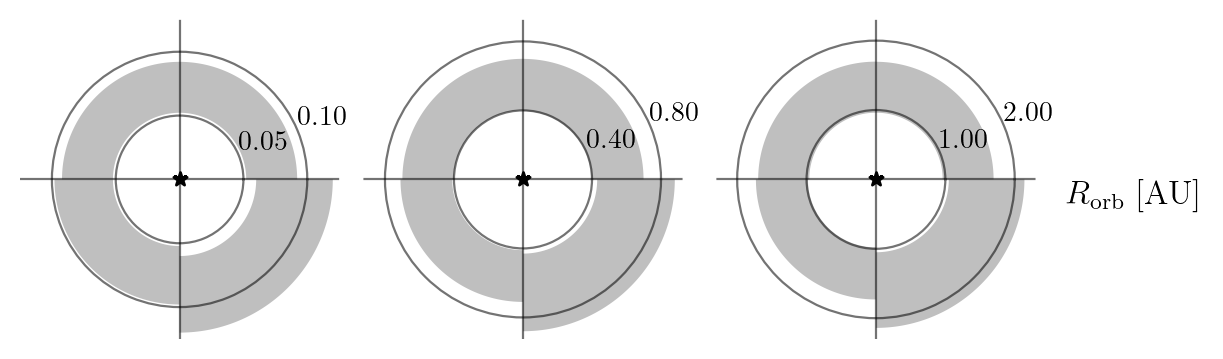

In [143]:
# make a plot of the shifting habitable zone limits for different levels of 
# enrichment for the M5V star, to visually show how much the HZ extends 
# with increasing internal heat flux
# plot in a pie-like graph with different quadrants for different levels of enrichment, and show the HZ limits as concentric circles
fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(6, 6), dpi=200, subplot_kw={'projection': 'polar'}, constrained_layout=True)

# plot an 'M star' at the center in red
ax1.scatter(0, 0, color='black', s=25, marker='*', zorder=1)
ax2.scatter(0, 0, color='black', s=25, marker='*', zorder=1)
ax3.scatter(0, 0, color='black', s=25, marker='*', zorder=1)

# plot standard habitable zones in first quadrant, with the inner and outer limits
ax1.fill_between(x=np.linspace(np.pi / 2, 0, 100), y1=m_limits_1[0], y2=m_limits_1[1], color='grey', alpha=0.50, label='M5V HZ', edgecolor='none')
ax2.fill_between(x=np.linspace(np.pi / 2, 0, 100), y1=k_limits_1[0], y2=k_limits_1[1], color='grey', alpha=0.50, label='K5V HZ', edgecolor='none')
ax3.fill_between(x=np.linspace(np.pi / 2, 0, 100), y1=g_limits_1[0], y2=g_limits_1[1], color='grey', alpha=0.50, label='G2V HZ', edgecolor='none')
ax.text(np.pi/4, 2.50, 'Solar [X/Fe]', ha='center')
#ax.text(np.pi/7, 2.5, 'M5V HZ width: '+str(np.round((m_limits_1[1]-m_limits_1[0]), 2))+
                    #'\nK5V HZ width: '+str(np.round(k_limits_1[1]-k_limits_1[0], 2))+
                    #'\nG2V HZ width: '+str(np.round(g_limits_1[1]-g_limits_1[0], 2)), fontsize=8)


# plot Roederer enhanced limits in second quadrant
ax1.fill_between(x=np.linspace(-np.pi, -3*np.pi/2, 100), y1=m_limits_enhanced_1_00_1[0], y2=m_limits_enhanced_1_00_1[1], color='grey', alpha=0.50, edgecolor='None') #label='M5V HZ (Roederer et al. 2019)', edgecolor='none')
ax2.fill_between(x=np.linspace(-np.pi, -3*np.pi/2, 100), y1=k_limits_enhanced_1_00_1[0], y2=k_limits_enhanced_1_00_1[1], color='grey', alpha=0.50, edgecolor='None') #label='K5V HZ (Roederer et al. 2019)', edgecolor='none')
ax3.fill_between(x=np.linspace(-np.pi, -3*np.pi/2, 100), y1=g_limits_enhanced_1_00_1[0], y2=g_limits_enhanced_1_00_1[1], color='grey', alpha=0.50, edgecolor='None') #label='G2V HZ (Roederer et al. 2019)', edgecolor='none')
#ax.text(4.30*np.pi/6, 2.55, ' [X/Fe] = +2.2 \n (Roederer et al. 2024)', ha='right')
ax.text(4.30*np.pi/6, 2.20, ' [X/Fe] = +1.0', ha='right')
#ax.text(4.60*np.pi/5, 4.25, 'M5V HZ width: '+str(np.round((m_limits_roeder_enhanced_1[1]-m_limits_roeder_enhanced_1[0]), 2))+
                          #'\nK5V HZ width: '+str(np.round(k_limits_roeder_enhanced_1[1]-k_limits_roeder_enhanced_1[0], 2))+
                          #'\nG2V HZ width: '+str(np.round(g_limits_roeder_enhanced_1[1]-g_limits_roeder_enhanced_1[0], 2)), fontsize=8)


# then plot the 20% in the third quadrant
ax1.fill_between(x=np.linspace(-np.pi/2, -np.pi, 100), y1=m_limits_enhanced_2_00_1[0], y2=m_limits_enhanced_2_00_1[1], color='grey', alpha=0.50, edgecolor='None')# label='M5V HZ (20% extension)', edgecolor='none')
ax2.fill_between(x=np.linspace(-np.pi/2, -np.pi, 100), y1=k_limits_enhanced_2_00_1[0], y2=k_limits_enhanced_2_00_1[1], color='grey', alpha=0.50, edgecolor='None')# label='K5V HZ (20% extension)', edgecolor='none')
ax3.fill_between(x=np.linspace(-np.pi/2, -np.pi, 100), y1=g_limits_enhanced_2_00_1[0], y2=g_limits_enhanced_2_00_1[1], color='grey', alpha=0.50, edgecolor='None')# label='G2V HZ (20% extension)', edgecolor='none')
ax.text(-4.75*np.pi/7, 2.25, '[X/Fe] = +2.00', ha='right')
#ax.text(-4.4*np.pi/5, 4.25, 'M5V HZ width: '+str(np.round((m_limits_enhanced_2_50_1[1]-m_limits_enhanced_2_50_1[0]), 2))+
#                          '\nK5V HZ width: '+str(np.round(k_limits_enhanced_2_50_1[1]-k_limits_enhanced_2_50_1[0], 2))+
#                          '\nG2V HZ width: '+str(np.round(g_limits_enhanced_2_50_1[1]-g_limits_enhanced_2_50_1[0], 2)), fontsize=8)

# and 100% extension limits in the fourth quadrant
#ax.fill_between(x=np.linspace(-np.pi, -3*np.pi/2, 100), y1=m_limits_enhanced_3_00[0], y2=m_limits_enhanced_3_00[1], color='firebrick', alpha=0.50, edgecolor='None')#label='M5V HZ (100% extension)', edgecolor='none')
#ax.fill_between(x=np.linspace(-np.pi, -3*np.pi/2, 100), y1=k_limits_enhanced_3_00[0], y2=k_limits_enhanced_3_00[1], color='orange', alpha=0.50, edgecolor='None')#label='K5V HZ (100% extension)', edgecolor='none')
#ax.fill_between(x=np.linspace(-np.pi, -3*np.pi/2, 100), y1=g_limits_3_00[0], y2=g_limits_3_00[1], color='green', alpha=0.50, edgecolor='None')#label='G2V HZ (100% extension)', edgecolor='none')
#ax.text(4.30*np.pi/6, 2.65, '[X/Fe] = +3.00', ha='right')

ax1.fill_between(x=np.linspace(0, -np.pi/2, 100), y1=m_limits_enhanced_3_00_1[0], y2=m_limits_enhanced_3_00_1[1], color='grey', alpha=0.50, edgecolor='None')#label='M5V HZ (100% extension)', edgecolor='none')
ax2.fill_between(x=np.linspace(0, -np.pi/2, 100), y1=k_limits_enhanced_3_00_1[0], y2=k_limits_enhanced_3_00_1[1], color='grey', alpha=0.50, edgecolor='None')#label='K5V HZ (100% extension)', edgecolor='none')
ax3.fill_between(x=np.linspace(0, -np.pi/2, 100), y1=g_limits_enhanced_3_00_1[0], y2=g_limits_enhanced_3_00_1[1], color='grey', alpha=0.50, edgecolor='None')#label='G2V HZ (100% extension)', edgecolor='none')
#ax3.text(-3*np.pi/10, 2.35, '[X/Fe] = +3.00', ha='left')
#ax.text(-np.pi/5.5, 2.65, 'M5V HZ width: '+str(np.round((m_limits_enhanced_3_00_1[1]-m_limits_enhanced_3_00_1[0]), 2))+
#                        '\nK5V HZ width: '+str(np.round(k_limits_enhanced_3_00_1[1]-k_limits_enhanced_3_00_1[0], 2))+
#                        '\nG2V HZ width: '+str(np.round(g_limits_enhanced_3_00_1[1]-g_limits_enhanced_3_00_1[0], 2)), fontsize=8)

# Add orbital radius label to the right
ax3.text(-np.pi/32, 3.75, '$R_{\mathrm{orb}}$ [AU]', ha='center', fontsize=12)

ax1.set_rorigin(0); ax1.set_rmax(0.125); 
ax1.set_rticks([0.05, 0.10])
ax1.set_yticklabels(['0.05', '0.10'], fontsize=10)  # Smaller font for radial ticks
ax1.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2])
ax1.set_xticklabels(['', '', '', ''])

ax2.set_rorigin(0); ax2.set_rmax(0.925); 
ax2.set_rticks([0.4, 0.80])
ax2.set_yticklabels(['0.40', '0.80'], fontsize=10)  # Smaller font for radial ticks
ax2.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2])
ax2.set_xticklabels(['', '', '', ''])

ax3.set_rorigin(0); ax3.set_rmax(2.3); 
ax3.set_rticks([1.0, 2.0])
ax3.set_yticklabels(['1.00', '2.00'], fontsize=10)  # Smaller font for radial ticks
ax3.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2])
ax3.set_xticklabels(['', '', '', ''])


#ax.set_rlabel_position(0)  # Position radial labels at bottom
#ax1.set_yticklabels(['0.5', '1.0', '2.0'], fontsize=12)  # Smaller font for radial ticks
ax1.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2])
ax1.set_xticklabels(['', '', '', '']); ax2.set_xticklabels(['', '', '', '']); ax3.set_xticklabels(['', '', '', ''])
ax1.spines['polar'].set_visible(False); ax2.spines['polar'].set_visible(False); ax3.spines['polar'].set_visible(False)  # Hide the outer circular border
ax1.grid(alpha=0.55, color='black'); ax2.grid(alpha=0.55, color='black'); ax3.grid(alpha=0.55, color='black')
#ax1.legend(loc=(-.60, 0.38), fontsize=10, framealpha=0.9)

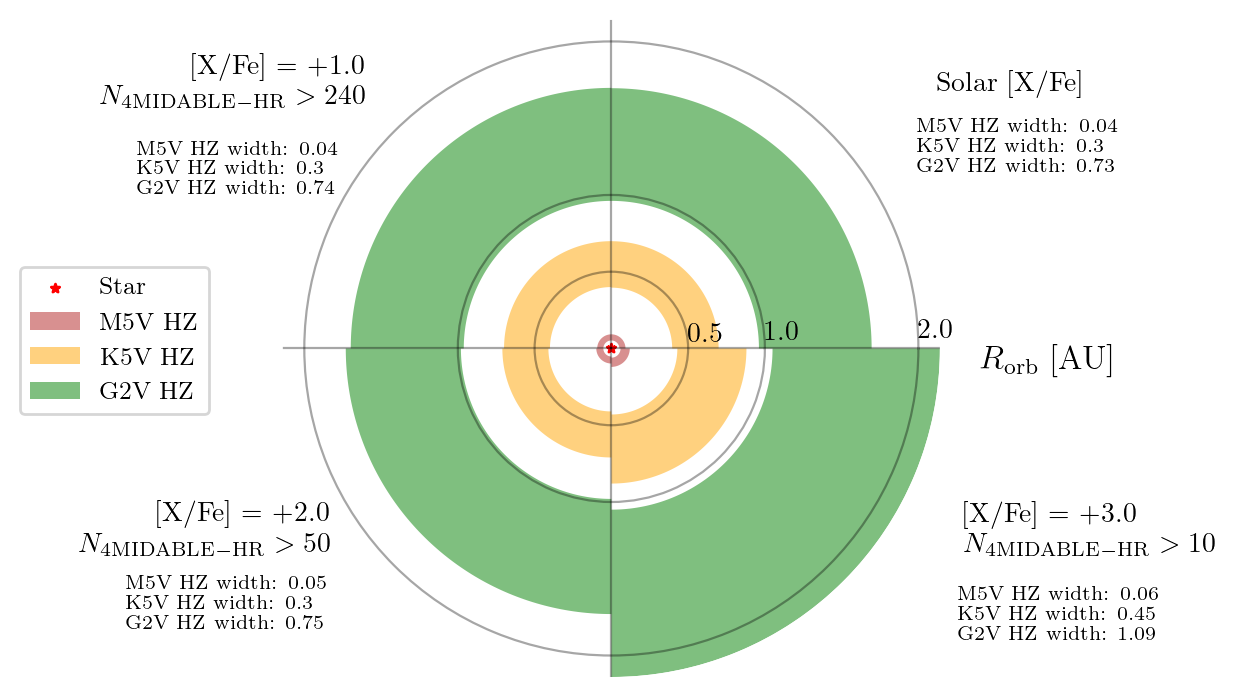

In [47]:
# make a plot of the shifting habitable zone limits for different levels of 
# enrichment for the M5V star, to visually show how much the HZ extends 
# with increasing internal heat flux
# plot in a pie-like graph with different quadrants for different levels of enrichment, and show the HZ limits as concentric circles
fig, ax = plt.subplots(figsize=(6, 6), dpi=200, subplot_kw={'projection': 'polar'}, constrained_layout=True)

# plot an 'M star' at the center in red
ax.scatter(0, 0, color='red', s=10, label='Star', marker='*')

# plot standard habitable zones in first quadrant, with the inner and outer limits
ax.fill_between(x=np.linspace(np.pi / 2, 0, 100), y1=m_limits_1[0], y2=m_limits_1[1], color='firebrick', alpha=0.50, label='M5V HZ', edgecolor='none')
ax.fill_between(x=np.linspace(np.pi / 2, 0, 100), y1=k_limits_1[0], y2=k_limits_1[1], color='orange', alpha=0.50, label='K5V HZ', edgecolor='none')
ax.fill_between(x=np.linspace(np.pi / 2, 0, 100), y1=g_limits_1[0], y2=g_limits_1[1], color='green', alpha=0.50, label='G2V HZ', edgecolor='none')
ax.text(np.pi/5.5, 3.1, 'Solar [X/Fe]', ha='center', fontsize=10)
ax.text(np.pi/6, 2.3, 'M5V HZ width: '+str(np.round((m_limits_1[1]-m_limits_1[0]), 2))+
                    '\nK5V HZ width: '+str(np.round(k_limits_1[1]-k_limits_1[0], 2))+
                    '\nG2V HZ width: '+str(np.round(g_limits_1[1]-g_limits_1[0], 2)), fontsize=7)

# plot +1 enhanced limits in second quadrant
ax.fill_between(x=np.linspace(-np.pi, -3*np.pi/2, 100), y1=m_limits_enhanced_1_00_1[0], y2=m_limits_enhanced_1_00_1[1], color='firebrick', alpha=0.50, edgecolor='None') #label='M5V HZ (Roederer et al. 2019)', edgecolor='none')
ax.fill_between(x=np.linspace(-np.pi, -3*np.pi/2, 100), y1=k_limits_enhanced_1_00_1[0], y2=k_limits_enhanced_1_00_1[1], color='orange', alpha=0.50, edgecolor='None') #label='K5V HZ (Roederer et al. 2019)', edgecolor='none')
ax.fill_between(x=np.linspace(-np.pi, -3*np.pi/2, 100), y1=g_limits_enhanced_1_00_1[0], y2=g_limits_enhanced_1_00_1[1], color='green', alpha=0.50, edgecolor='None') #label='G2V HZ (Roederer et al. 2019)', edgecolor='none')
ax.text(4.5*np.pi/6, 2.25, ' [X/Fe] = +1.0 \n $N_{\mathrm{4MIDABLE-HR}} > 240$', ha='right', fontsize=10)
ax.text(4.5*np.pi/5, 3.25, 'M5V HZ width: '+str(np.round((m_limits_enhanced_1_00_1[1]-m_limits_enhanced_1_00_1[0]), 2))+
                            '\nK5V HZ width: '+str(np.round(k_limits_enhanced_1_00_1[1]-k_limits_enhanced_1_00_1[0], 2))+
                            '\nG2V HZ width: '+str(np.round(g_limits_enhanced_1_00_1[1]-g_limits_enhanced_1_00_1[0], 2)), fontsize=7)

# then plot +2 in the third quadrant
ax.fill_between(x=np.linspace(-np.pi/2, -np.pi, 100), y1=m_limits_enhanced_2_00_1[0], y2=m_limits_enhanced_2_00_1[1], color='firebrick', alpha=0.50, edgecolor='None')# label='M5V HZ (20% extension)', edgecolor='none')
ax.fill_between(x=np.linspace(-np.pi/2, -np.pi, 100), y1=k_limits_enhanced_2_00_1[0], y2=k_limits_enhanced_2_00_1[1], color='orange', alpha=0.50, edgecolor='None')# label='K5V HZ (20% extension)', edgecolor='none')
ax.fill_between(x=np.linspace(-np.pi/2, -np.pi, 100), y1=g_limits_enhanced_2_00_1[0], y2=g_limits_enhanced_2_00_1[1], color='green', alpha=0.50, edgecolor='None')# label='G2V HZ (20% extension)', edgecolor='none')
ax.text(-4*np.pi/5, 2.25, '[X/Fe] = +2.0 \n $N_{\mathrm{4MIDABLE-HR}} > 50$', ha='right', fontsize=10)
ax.text(-5*np.pi/6, 3.65, 'M5V HZ width: '+str(np.round((m_limits_enhanced_2_00_1[1]-m_limits_enhanced_2_00_1[0]), 2))+
                            '\nK5V HZ width: '+str(np.round(k_limits_enhanced_2_00_1[1]-k_limits_enhanced_2_00_1[0], 2))+
                            '\nG2V HZ width: '+str(np.round(g_limits_enhanced_2_00_1[1]-g_limits_enhanced_2_00_1[0], 2)), fontsize=7, ha='left')

# and +3 limits in the fourth quadrant
ax.fill_between(x=np.linspace(0, -np.pi/2, 100), y1=m_limits_enhanced_3_00_1[0], y2=m_limits_enhanced_3_00_1[1], color='firebrick', alpha=0.50, edgecolor='None')#label='M5V HZ (100% extension)', edgecolor='none')
ax.fill_between(x=np.linspace(0, -np.pi/2, 100), y1=k_limits_enhanced_3_00_1[0], y2=k_limits_enhanced_3_00_1[1], color='orange', alpha=0.50, edgecolor='None')#label='K5V HZ (100% extension)', edgecolor='none')
ax.fill_between(x=np.linspace(0, -np.pi/2, 100), y1=g_limits_enhanced_3_00_1[0], y2=g_limits_enhanced_3_00_1[1], color='green', alpha=0.50, edgecolor='None')#label='G2V HZ (100% extension)', edgecolor='none')
ax.text(-np.pi/6.0, 2.65, ' [X/Fe] = +3.0 \n $N_{\mathrm{4MIDABLE-HR}} > 10$', ha='left', fontsize=10)
ax.text(-np.pi/4.5, 2.95, 'M5V HZ width: '+str(np.round((m_limits_enhanced_3_00_1[1]-m_limits_enhanced_3_00_1[0]), 2))+
                          '\nK5V HZ width: '+str(np.round(k_limits_enhanced_3_00_1[1]-k_limits_enhanced_3_00_1[0], 2))+
                          '\nG2V HZ width: '+str(np.round(g_limits_enhanced_3_00_1[1]-g_limits_enhanced_3_00_1[0], 2)), fontsize=7, ha='left')

# Add orbital radius label to the right
ax.text(-np.pi/64, 2.85, '$R_{\mathrm{orb}}$ [AU]', ha='center', fontsize=12)

ax.set_rorigin(0); ax.set_rmax(2.14); 
ax.set_rticks([0.5, 1.0, 2.0])
ax.set_rlabel_position(1)  # Position radial labels at bottom
ax.set_yticklabels(['0.5', '1.0', '2.0'])  # Smaller font for radial ticks
ax.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2])
ax.set_xticklabels(['', '', '', ''])
ax.spines['polar'].set_visible(False)  # Hide the outer circular border
ax.grid(alpha=0.35, color='black')

ax.legend(loc=(-.40, 0.40), fontsize=9)

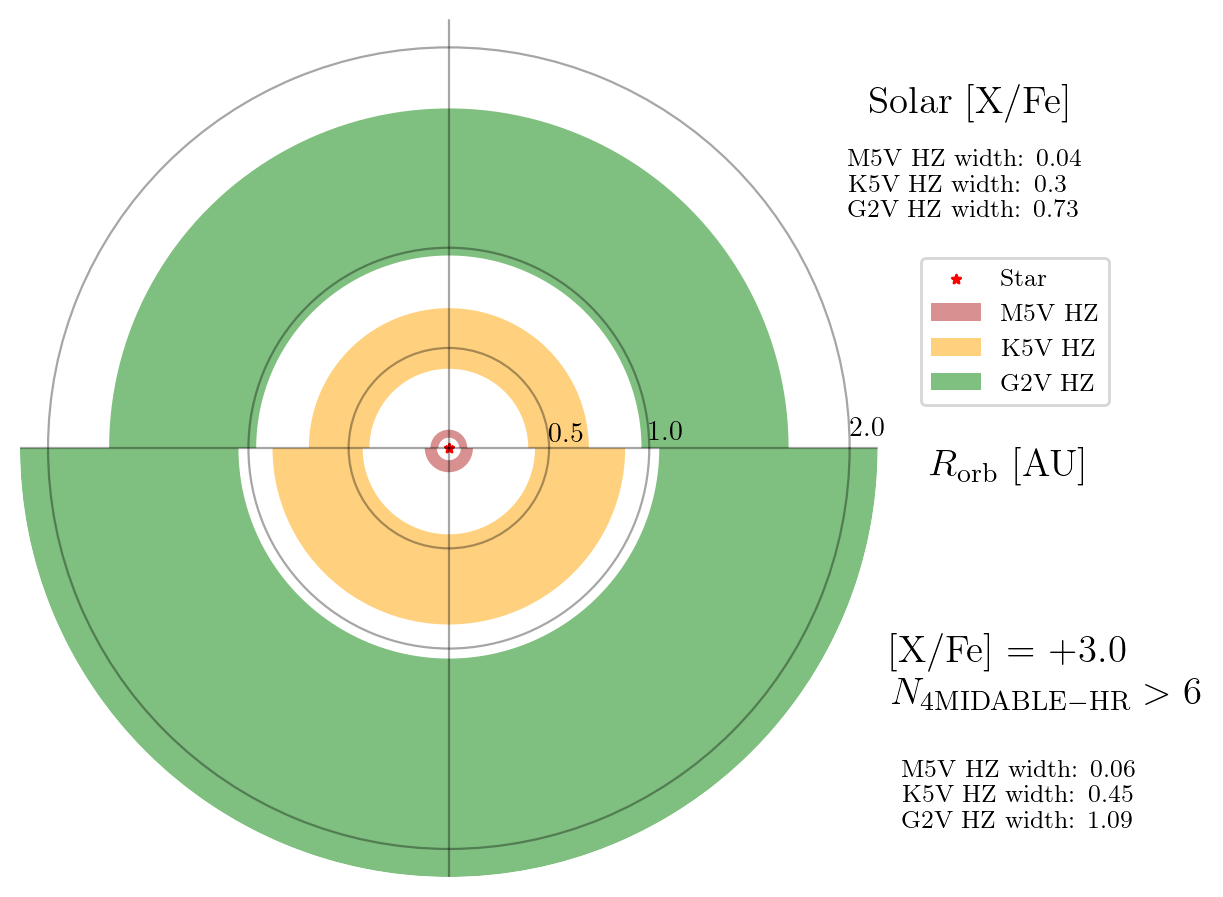

In [81]:
# make a plot of the shifting habitable zone limits for different levels of 
# enrichment for the M5V star, to visually show how much the HZ extends 
# with increasing internal heat flux
# plot in a pie-like graph with different quadrants for different levels of enrichment, and show the HZ limits as concentric circles
fig, ax = plt.subplots(figsize=(6, 6), dpi=200, subplot_kw={'projection': 'polar'}, constrained_layout=True)

# plot a star at the center in red
ax.scatter(0, 0, color='red', s=10, label='Star', marker='*')

# plot Solar-like habitable zones in left half, with the inner and outer limits
ax.fill_between(x=np.linspace(0, np.pi, 100), y1=m_limits_1[0], y2=m_limits_1[1], color='firebrick', alpha=0.50, label='M5V HZ', edgecolor='none')
ax.fill_between(x=np.linspace(0, np.pi, 100), y1=k_limits_1[0], y2=k_limits_1[1], color='orange', alpha=0.50, label='K5V HZ', edgecolor='none')
ax.fill_between(x=np.linspace(0, np.pi, 100), y1=g_limits_1[0], y2=g_limits_1[1], color='green', alpha=0.50, label='G2V HZ', edgecolor='none')
ax.text(np.pi/5.5, 3.1, 'Solar [X/Fe]', ha='center', fontsize=14)
ax.text(np.pi/6, 2.3, 'M5V HZ width: '+str(np.round((m_limits_1[1]-m_limits_1[0]), 2))+
                    '\nK5V HZ width: '+str(np.round(k_limits_1[1]-k_limits_1[0], 2))+
                    '\nG2V HZ width: '+str(np.round(g_limits_1[1]-g_limits_1[0], 2)), fontsize=9)

# and +3 limits in the right half
ax.fill_between(x=np.linspace(np.pi, 2*np.pi, 100), y1=m_limits_enhanced_3_00_1[0], y2=m_limits_enhanced_3_00_1[1], color='firebrick', alpha=0.50, edgecolor='None')#label='M5V HZ (100% extension)', edgecolor='none')
ax.fill_between(x=np.linspace(np.pi, 2*np.pi, 100), y1=k_limits_enhanced_3_00_1[0], y2=k_limits_enhanced_3_00_1[1], color='orange', alpha=0.50, edgecolor='None')#label='K5V HZ (100% extension)', edgecolor='none')
ax.fill_between(x=np.linspace(np.pi, 2*np.pi, 100), y1=g_limits_enhanced_3_00_1[0], y2=g_limits_enhanced_3_00_1[1], color='green', alpha=0.50, edgecolor='None')#label='G2V HZ (100% extension)', edgecolor='none')
ax.text(-np.pi/6.0, 2.55, ' [X/Fe] = +3.0 \n $N_{\mathrm{4MIDABLE-HR}} > 6$', ha='left', fontsize=14)
ax.text(-np.pi/4.5, 2.95, 'M5V HZ width: '+str(np.round((m_limits_enhanced_3_00_1[1]-m_limits_enhanced_3_00_1[0]), 2))+
                          '\nK5V HZ width: '+str(np.round(k_limits_enhanced_3_00_1[1]-k_limits_enhanced_3_00_1[0], 2))+
                          '\nG2V HZ width: '+str(np.round(g_limits_enhanced_3_00_1[1]-g_limits_enhanced_3_00_1[0], 2)), fontsize=9, ha='left')

# Add orbital radius label to the right
ax.text(-np.pi/64, 2.80, '$R_{\mathrm{orb}}$ [AU]', ha='center', fontsize=14)

ax.set_rorigin(0); ax.set_rmax(2.14); 
ax.set_rticks([0.5, 1.0, 2.0])
ax.set_rlabel_position(1)  # Position radial labels at bottom
ax.set_yticklabels(['0.5', '1.0', '2.0'])  # Smaller font for radial ticks
ax.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2])
ax.set_xticklabels(['', '', '', ''])
ax.spines['polar'].set_visible(False)  # Hide the outer circular border
ax.grid(alpha=0.35, color='black')

ax.legend(loc=(1.05, 0.55), fontsize=9)

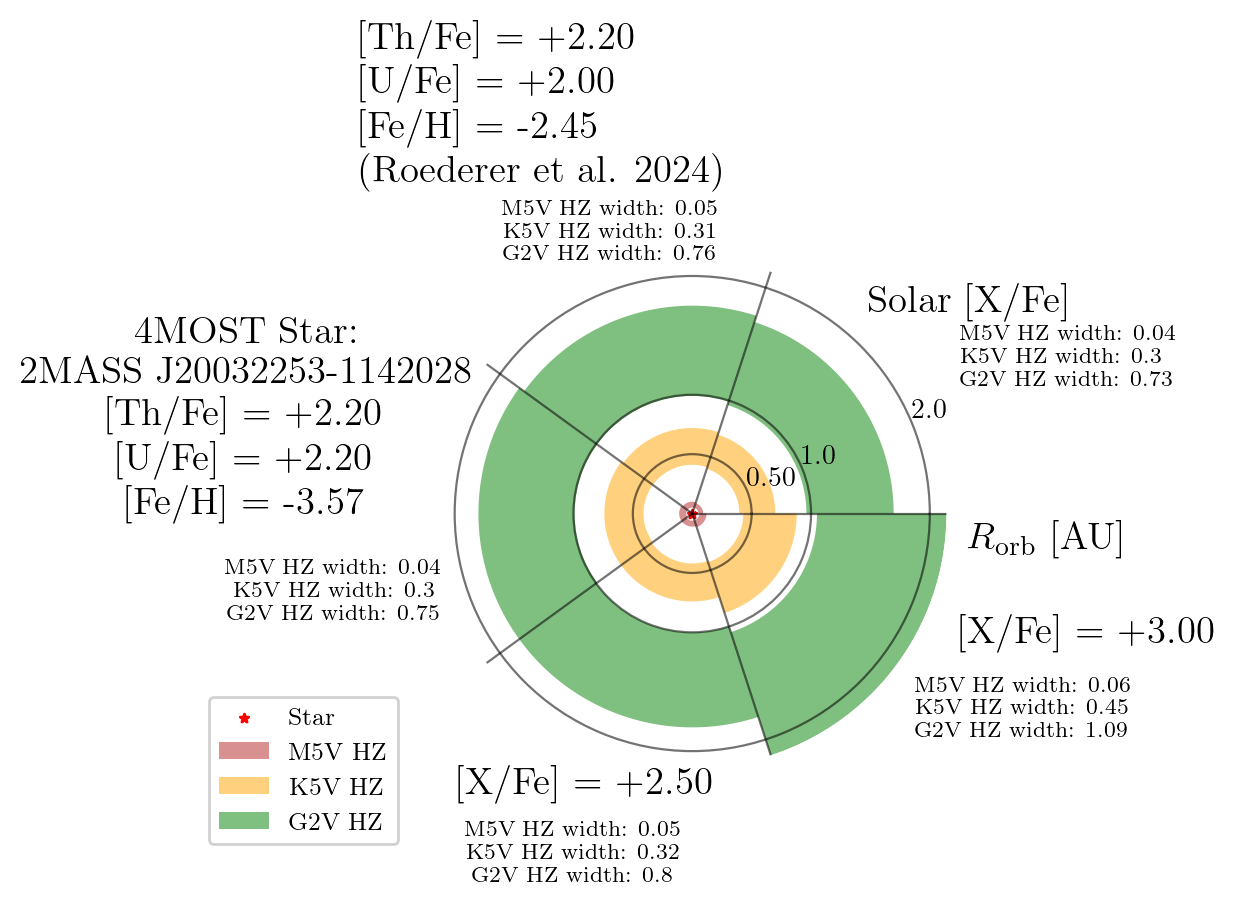

In [45]:
# make a plot of the shifting habitable zone limits for different levels of 
# enrichment for the M5V star, to visually show how much the HZ extends 
# with increasing internal heat flux
# plot in a pie-like graph with different quadrants for different levels of enrichment, and show the HZ limits as concentric circles
fig, ax = plt.subplots(figsize=(6, 6), dpi=200, subplot_kw={'projection': 'polar'}, constrained_layout=True)

# plot an 'M star' at the center in red
ax.scatter(0, 0, color='red', s=10, label='Star', marker='*')

# plot standard (Solar) habitable zones in first quadrant, with the inner and outer limits
ax.fill_between(x=np.linspace(2*np.pi / 5, 0, 100), y1=m_limits_1[0], y2=m_limits_1[1], color='firebrick', alpha=0.50, label='M5V HZ', edgecolor='none')
ax.fill_between(x=np.linspace(2*np.pi / 5, 0, 100), y1=k_limits_1[0], y2=k_limits_1[1], color='orange', alpha=0.50, label='K5V HZ', edgecolor='none')
ax.fill_between(x=np.linspace(2*np.pi / 5, 0, 100), y1=g_limits_1[0], y2=g_limits_1[1], color='green', alpha=0.50, label='G2V HZ', edgecolor='none')
ax.text(np.pi/5, 2.90, 'Solar [X/Fe]', ha='center')
ax.text(np.pi/7, 2.5, 'M5V HZ width: '+str(np.round((m_limits_1[1]-m_limits_1[0]), 2))+
                    '\nK5V HZ width: '+str(np.round(k_limits_1[1]-k_limits_1[0], 2))+
                    '\nG2V HZ width: '+str(np.round(g_limits_1[1]-g_limits_1[0], 2)), fontsize=8)
#ax.text(np.pi/5, 2.95, '4MOST $N_{stars}$([X/Fe]) = $10^5$', ha='center', fontsize=8)

# plot Roederer enhanced (+2.2 dex) limits in second quadrant
ax.fill_between(x=np.linspace(2*np.pi / 5, 4*np.pi / 5, 100), y1=m_limits_roeder_enhanced_1[0], y2=m_limits_roeder_enhanced_1[1], color='firebrick', alpha=0.50, edgecolor='None') #label='M5V HZ (Roederer et al. 2019)', edgecolor='none')
ax.fill_between(x=np.linspace(2*np.pi / 5, 4*np.pi / 5, 100), y1=k_limits_roeder_enhanced_1[0], y2=k_limits_roeder_enhanced_1[1], color='orange', alpha=0.50, edgecolor='None') #label='K5V HZ (Roederer et al. 2019)', edgecolor='none')
ax.fill_between(x=np.linspace(2*np.pi / 5, 4*np.pi / 5, 100), y1=g_limits_roeder_enhanced_1[0], y2=g_limits_roeder_enhanced_1[1], color='green', alpha=0.50, edgecolor='None') #label='G2V HZ (Roederer et al. 2019)', edgecolor='none')
ax.text(6*np.pi/8, 3.95, ' [Th/Fe] = +2.20 \n [U/Fe] = +2.00 \n [Fe/H] = -2.45 \n (Roederer et al. 2024)', ha='left')
ax.text(3*np.pi/5, 2.25, 'M5V HZ width: '+str(np.round((m_limits_roeder_enhanced_1[1]-m_limits_roeder_enhanced_1[0]), 2))+
                    '\nK5V HZ width: '+str(np.round(k_limits_roeder_enhanced_1[1]-k_limits_roeder_enhanced_1[0], 2))+
                    '\nG2V HZ width: '+str(np.round(g_limits_roeder_enhanced_1[1]-g_limits_roeder_enhanced_1[0], 2)), ha='center', fontsize=8)

# plot a 4MOST star in the third quadrant
ax.fill_between(x=np.linspace(4*np.pi/5, 6*np.pi/5, 100), y1=m_limits_roeder_enhanced_1[0], y2=m_limits_enhanced_2_50_1[1], color='firebrick', alpha=0.50, edgecolor='None')# label='M5V HZ (20% extension)', edgecolor='none')
ax.fill_between(x=np.linspace(4*np.pi/5, 6*np.pi/5, 100), y1=k_limits_roeder_enhanced_1[0], y2=k_limits_enhanced_2_50_1[1], color='orange', alpha=0.50, edgecolor='None')# label='K5V HZ (20% extension)', edgecolor='none')
ax.fill_between(x=np.linspace(4*np.pi/5, 6*np.pi/5, 100), y1=g_limits_roeder_enhanced_1[0], y2=g_limits_enhanced_2_50_1[1], color='green', alpha=0.50, edgecolor='None')# label='G2V HZ (20% extension)', edgecolor='none')
ax.text(np.pi, 3.75, '4MOST Star: \n 2MASS J20032253-1142028 \n [Th/Fe] = +2.20 \n [U/Fe] = +2.20 \n [Fe/H] = -3.57', ha='center')
ax.text(12*np.pi/11, 3.15, 'M5V HZ width: '+str(np.round((m_limits_roeder_enhanced_1[1]-m_limits_enhanced_2_50_1[0]), 2))+
                            '\nK5V HZ width: '+str(np.round(k_limits_roeder_enhanced_1[1]-k_limits_enhanced_2_50_1[0], 2))+
                            '\nG2V HZ width: '+str(np.round(g_limits_roeder_enhanced_1[1]-g_limits_enhanced_2_50_1[0], 2)), ha='center', fontsize=8)

# then plot the +2.5 dex in the fourth quadrant
ax.fill_between(x=np.linspace(6*np.pi/5, 8*np.pi/5, 100), y1=m_limits_enhanced_2_50_1[0], y2=m_limits_enhanced_2_50_1[1], color='firebrick', alpha=0.50, edgecolor='None')# label='M5V HZ (20% extension)', edgecolor='none')
ax.fill_between(x=np.linspace(6*np.pi/5, 8*np.pi/5, 100), y1=k_limits_enhanced_2_50_1[0], y2=k_limits_enhanced_2_50_1[1], color='orange', alpha=0.50, edgecolor='None')# label='K5V HZ (20% extension)', edgecolor='none')
ax.fill_between(x=np.linspace(6*np.pi/5, 8*np.pi/5, 100), y1=g_limits_enhanced_2_50_1[0], y2=g_limits_enhanced_2_50_1[1], color='green', alpha=0.50, edgecolor='None')# label='G2V HZ (20% extension)', edgecolor='none')
ax.text(7*np.pi/5, 2.85, '[X/Fe] = +2.50 \n ', ha='center')
ax.text(7*np.pi/5, 3.25, 'M5V HZ width: '+str(np.round((m_limits_enhanced_2_50_1[1]-m_limits_enhanced_2_50_1[0]), 2))+
                            '\nK5V HZ width: '+str(np.round(k_limits_enhanced_2_50_1[1]-k_limits_enhanced_2_50_1[0], 2))+
                            '\nG2V HZ width: '+str(np.round(g_limits_enhanced_2_50_1[1]-g_limits_enhanced_2_50_1[0], 2)), ha='center', fontsize=8)

# and the +3.0 dex in the fifth quadrant
ax.fill_between(x=np.linspace(0, -2*np.pi/5, 100), y1=m_limits_enhanced_3_00_1[0], y2=m_limits_enhanced_3_00_1[1], color='firebrick', alpha=0.50, edgecolor='None')#label='M5V HZ (100% extension)', edgecolor='none')
ax.fill_between(x=np.linspace(0, -2*np.pi/5, 100), y1=k_limits_enhanced_3_00_1[0], y2=k_limits_enhanced_3_00_1[1], color='orange', alpha=0.50, edgecolor='None')#label='K5V HZ (100% extension)', edgecolor='none')
ax.fill_between(x=np.linspace(0, -2*np.pi/5, 100), y1=g_limits_enhanced_3_00_1[0], y2=g_limits_enhanced_3_00_1[1], color='green', alpha=0.50, edgecolor='None')#label='G2V HZ (100% extension)', edgecolor='none')
ax.text(-np.pi/7, 2.5, '[X/Fe] = +3.00', ha='left')
ax.text(-np.pi/4, 2.65, 'M5V HZ width: '+str(np.round((m_limits_enhanced_3_00_1[1]-m_limits_enhanced_3_00_1[0]), 2))+
                        '\nK5V HZ width: '+str(np.round(k_limits_enhanced_3_00_1[1]-k_limits_enhanced_3_00_1[0], 2))+
                        '\nG2V HZ width: '+str(np.round(g_limits_enhanced_3_00_1[1]-g_limits_enhanced_3_00_1[0], 2)), fontsize=8)

# Add orbital radius label to the right
ax.text(-np.pi/32, 3.0, '$R_{\mathrm{orb}}$ [AU]', ha='center')

# add 4MOST accessible region
#ax.fill_between(x=np.linspace(0, -np.pi/3, 100), y1=0.05, y2=2.14, color='gray', alpha=0.20, zorder=0, edgecolor='None')
#ax.fill_between(x=np.linspace(0, -2*np.pi/3, 100), y1=0.05, y2=2.14, color='gray', alpha=0.20, zorder=0, edgecolor='None')
#ax.fill_between(x=np.linspace(0, -3*np.pi/3, 100), y1=0.05, y2=2.14, color='gray', alpha=0.20, zorder=0, edgecolor='None')
#ax.fill_between(x=np.linspace(0, -4*np.pi/3, 100), y1=0.05, y2=2.14, color='gray', alpha=0.20, zorder=0, edgecolor='None')
#ax.fill_between(x=np.linspace(0, -5*np.pi/3, 100), y1=0.05, y2=2.14, color='gray', alpha=0.20, zorder=0, edgecolor='None')

ax.set_rorigin(0); ax.set_rmax(2.14); 
ax.set_rticks([0.5, 1.0, 2.0])
ax.set_yticklabels(['0.50', '1.0', '2.0'])  # Smaller font for radial ticks
ax.set_xticks([0, 2*np.pi/5, 4*np.pi/5, 6*np.pi/5, 8*np.pi/5])
ax.set_xticklabels(['', '', '', '', ''])
ax.spines['polar'].set_visible(False)  # Hide the outer circular border
ax.grid(alpha=0.55, color='black')
ax.legend(loc=(-0.45,-0.15), fontsize=9, framealpha=0.9)

In [46]:
# standard HZ limits for 8 earth mass planet
m_limits_8 = (0.05, 0.09)
k_limits_8 = (0.40, 0.70)
g_limits_8 = (0.98, 1.70)

# set limits for extensions to habitble zones using hz_limits_by_star
m_limits_enhanced_1_00_8 = ()
m_limits_enhanced_1_50_8 = ()
m_limits_roeder_enhanced_8 = (0.06, 0.10)
m_limits_enhanced_2_50_8 = (0.06, 0.11)
m_limits_enhanced_3_00_8 = (0.07, 0.38)
#
k_limits_enhanced_1_00_1 = ()
k_limits_enhanced_1_50_1 = ()
k_limits_roeder_enhanced_8 = (0.41, 0.75)
k_limits_enhanced_2_50_8 = (0.42, 0.83)
k_limits_enhanced_3_00_8 = (0.74, 2.89)
#
g_limits_enhanced_1_00_1 = ()
g_limits_enhanced_1_50_1 = ()
g_limits_roeder_enhanced_8 = (1.01, 1.84)
g_limits_2_50_8 = (1.03, 2.01)
g_limits_3_00_8 = (1.19, 7.05)
#g_limits_3_50 = (1.31, 4.66)


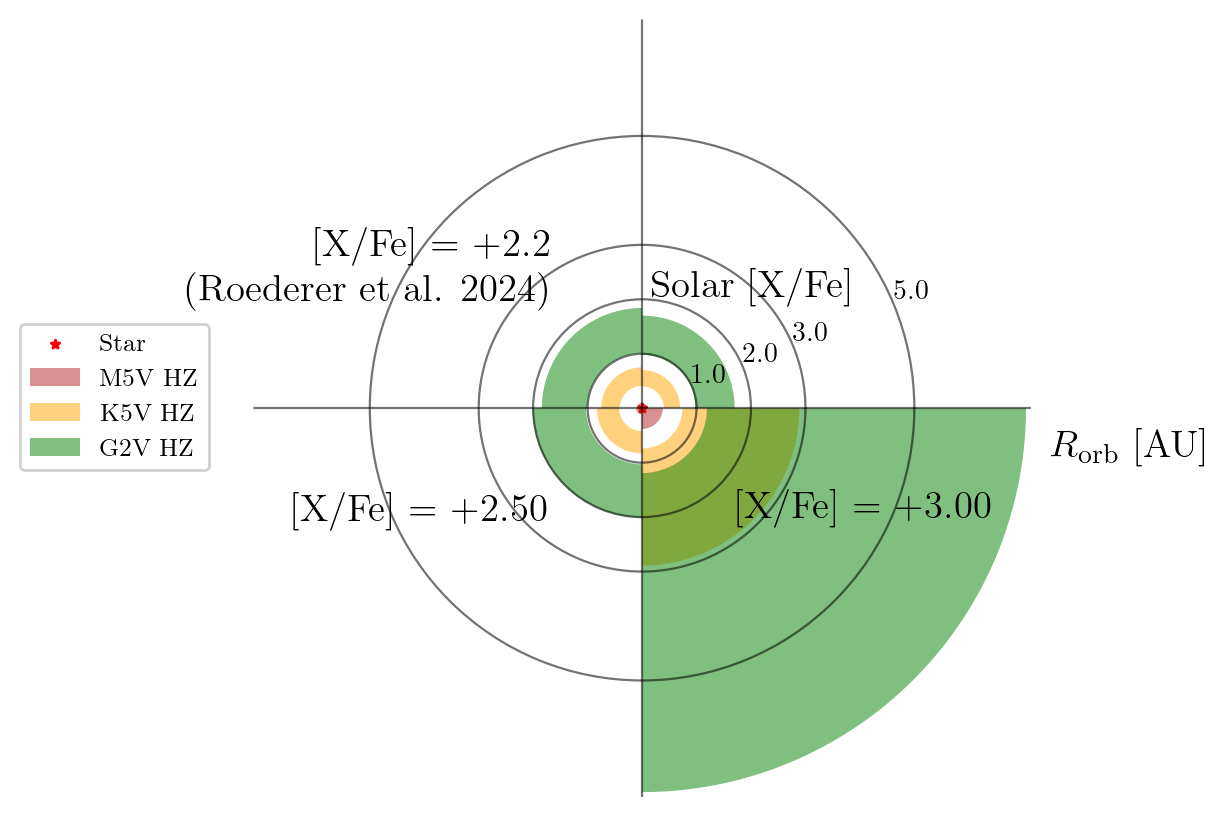

In [47]:
# make a plot of the shifting habitable zone limits for different levels of 
# enrichment for the M5V star, to visually show how much the HZ extends 
# with increasing internal heat flux
# THIS TIME FOR AN 8 EARTH MASS PLANET
# plot in a pie-like graph with different quadrants for different levels of enrichment, and show the HZ limits as concentric circles
fig, ax = plt.subplots(figsize=(6, 6), dpi=200, subplot_kw={'projection': 'polar'}, constrained_layout=True)

# plot an 'M star' at the center in red
ax.scatter(0, 0, color='red', s=10, label='Star', marker='*')

# plot standard habitable zones in first quadrant, with the inner and outer limits
ax.fill_between(x=np.linspace(np.pi / 2, 0, 100), y1=m_limits_8[0], y2=m_limits_8[1], color='firebrick', alpha=0.50, label='M5V HZ', edgecolor='none')
ax.fill_between(x=np.linspace(np.pi / 2, 0, 100), y1=k_limits_8[0], y2=k_limits_8[1], color='orange', alpha=0.50, label='K5V HZ', edgecolor='none')
ax.fill_between(x=np.linspace(np.pi / 2, 0, 100), y1=g_limits_8[0], y2=g_limits_8[1], color='green', alpha=0.50, label='G2V HZ', edgecolor='none')
ax.text(np.pi/4, 2.90, 'Solar [X/Fe]', ha='center')

# plot Roederer enhanced limits in second quadrant
ax.fill_between(x=np.linspace(-np.pi, -3*np.pi/2, 100), y1=m_limits_roeder_enhanced_8[0], y2=m_limits_roeder_enhanced_8[1], color='firebrick', alpha=0.50, edgecolor='None') #label='M5V HZ (Roederer et al. 2019)', edgecolor='none')
ax.fill_between(x=np.linspace(-np.pi, -3*np.pi/2, 100), y1=k_limits_roeder_enhanced_8[0], y2=k_limits_roeder_enhanced_8[1], color='orange', alpha=0.50, edgecolor='None') #label='K5V HZ (Roederer et al. 2019)', edgecolor='none')
ax.fill_between(x=np.linspace(-np.pi, -3*np.pi/2, 100), y1=g_limits_roeder_enhanced_8[0], y2=g_limits_roeder_enhanced_8[1], color='green', alpha=0.50, edgecolor='None') #label='G2V HZ (Roederer et al. 2019)', edgecolor='none')
ax.text(4.30*np.pi/6, 2.55, ' [X/Fe] = +2.2 \n (Roederer et al. 2024)', ha='right')

# then plot the 20% in the third quadrant
ax.fill_between(x=np.linspace(-np.pi/2, -np.pi, 100), y1=m_limits_enhanced_2_50_8[0], y2=m_limits_enhanced_2_50_8[1], color='firebrick', alpha=0.50, edgecolor='None')# label='M5V HZ (20% extension)', edgecolor='none')
ax.fill_between(x=np.linspace(-np.pi/2, -np.pi, 100), y1=k_limits_enhanced_2_50_8[0], y2=k_limits_enhanced_2_50_8[1], color='orange', alpha=0.50, edgecolor='None')# label='K5V HZ (20% extension)', edgecolor='none')
ax.fill_between(x=np.linspace(-np.pi/2, -np.pi, 100), y1=g_limits_2_50_8[0], y2=g_limits_2_50_8[1], color='green', alpha=0.50, edgecolor='None')# label='G2V HZ (20% extension)', edgecolor='none')
ax.text(-5*np.pi/7, 2.65, '[X/Fe] = +2.50', ha='right')

# and 100% extension limits in the fourth quadrant
ax.fill_between(x=np.linspace(0, -np.pi/2, 100), y1=m_limits_enhanced_3_00_8[0], y2=m_limits_enhanced_3_00_8[1], color='firebrick', alpha=0.50, edgecolor='None')#label='M5V HZ (100% extension)', edgecolor='none')
ax.fill_between(x=np.linspace(0, -np.pi/2, 100), y1=k_limits_enhanced_3_00_8[0], y2=k_limits_enhanced_3_00_8[1], color='orange', alpha=0.50, edgecolor='None')#label='K5V HZ (100% extension)', edgecolor='none')
ax.fill_between(x=np.linspace(0, -np.pi/2, 100), y1=g_limits_3_00_8[0], y2=g_limits_3_00_8[1], color='green', alpha=0.50, edgecolor='None')#label='G2V HZ (100% extension)', edgecolor='none')
ax.text(-3*np.pi/11, 2.65, '[X/Fe] = +3.00', ha='left')

# Add orbital radius label to the right
ax.text(-np.pi/32, 9.0, '$R_{\mathrm{orb}}$ [AU]', ha='center')

ax.set_rorigin(0); ax.set_rmax(7.14); 
ax.set_rticks([1.0, 2.0, 3.0, 5.0])
#ax.set_rlabel_position(0)  # Position radial labels at bottom
ax.set_yticklabels(['1.0', '2.0', '3.0', '5.0'])  # Smaller font for radial ticks
ax.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2])
ax.set_xticklabels(['', '', '', ''])
ax.spines['polar'].set_visible(False)  # Hide the outer circular border
ax.grid(alpha=0.55, color='black')
ax.legend(loc=(-.30, 0.42), fontsize=9, framealpha=0.9)

In [48]:
# lets make a plot of the shifting habitable zone limits for different levels of 
# enrichment for the M5V, K5V, and G2V star, to visually show how much the HZ extends 
# with increasing internal heat flux

## solid line == 1 earth mass
## dashed line == 5 earth mass
## dotted line == 8 earth mass

enhancements = np.linspace(0, 4, 100)

In [49]:
"""
Inner Edge of HZ for G2V Star at 1 Earth Mass
G2V_inner_limits = [0.95, 0.95, 0.96, 0.98, 0.99, 1.00, 1.05, 1.12, 1.17, 1.31]
	0.95		0.00
	0.95		1.00
	0.96		1.50
	0.98		2.00
	0.99		2.20 
	1.00		2.50
    1.05		3.00
    1.12		3.25
	1.17		3.34
	1.31		3.50

Outer Edge of HZ for G2V Star at 1 Earth Mass
G2V_outer_limits = [1.67, 1.67, 1.71, 1.73, 1.75, 1.80, 2.14, 3.07, 4.66, np.inf]
	1.67		0.00
	1.67		1.00
	1.71		1.50
	1.73		2.00
	1.75		2.20
	1.80		2.50
	2.14		3.00
	3.07		3.25
	4.66		3.34
    INF         3.83 (3.50)
"""

'\nInner Edge of HZ for G2V Star at 1 Earth Mass\nG2V_inner_limits = [0.95, 0.95, 0.96, 0.98, 0.99, 1.00, 1.05, 1.12, 1.17, 1.31]\n\t0.95\t\t0.00\n\t0.95\t\t1.00\n\t0.96\t\t1.50\n\t0.98\t\t2.00\n\t0.99\t\t2.20 \n\t1.00\t\t2.50\n    1.05\t\t3.00\n    1.12\t\t3.25\n\t1.17\t\t3.34\n\t1.31\t\t3.50\n\nOuter Edge of HZ for G2V Star at 1 Earth Mass\nG2V_outer_limits = [1.67, 1.67, 1.71, 1.73, 1.75, 1.80, 2.14, 3.07, 4.66, np.inf]\n\t1.67\t\t0.00\n\t1.67\t\t1.00\n\t1.71\t\t1.50\n\t1.73\t\t2.00\n\t1.75\t\t2.20\n\t1.80\t\t2.50\n\t2.14\t\t3.00\n\t3.07\t\t3.25\n\t4.66\t\t3.34\n    INF         3.83 (3.50)\n'

In [50]:
"""
Inner Edge of HZ for K5V Star at 1 Earth Mass
K5V_inner_limits = [0.40, 0.40, 0.40, 0.41, 0.41, 0.42, 0.43, 0.46, 0.48, 0.54]
	0.40		0.00
	0.40		1.00
	0.40		1.50
	0.41		2.00
	0.41		2.20
	0.42		2.50
    0.43		3.00
    0.46		3.25
	0.48		3.34
	0.54		3.50

Outer Edge of HZ for K5V Star at 1 Earth Mass
K5V_outer_limits = [0.70, 0.70, 0.70, 0.71, 0.72, 0.74, 0.88, 1.26, 1.91, np.inf]
	0.70		0.00 
	0.70		1.00
	0.70		1.50
	0.71		2.00
	0.72		2.20
	0.74		2.50
	0.88		3.00
	1.26		3.25
	1.91		3.34
	INF?		3.39 (3.50)

"""

'\nInner Edge of HZ for K5V Star at 1 Earth Mass\nK5V_inner_limits = [0.40, 0.40, 0.40, 0.41, 0.41, 0.42, 0.43, 0.46, 0.48, 0.54]\n\t0.40\t\t0.00\n\t0.40\t\t1.00\n\t0.40\t\t1.50\n\t0.41\t\t2.00\n\t0.41\t\t2.20\n\t0.42\t\t2.50\n    0.43\t\t3.00\n    0.46\t\t3.25\n\t0.48\t\t3.34\n\t0.54\t\t3.50\n\nOuter Edge of HZ for K5V Star at 1 Earth Mass\nK5V_outer_limits = [0.70, 0.70, 0.70, 0.71, 0.72, 0.74, 0.88, 1.26, 1.91, np.inf]\n\t0.70\t\t0.00 \n\t0.70\t\t1.00\n\t0.70\t\t1.50\n\t0.71\t\t2.00\n\t0.72\t\t2.20\n\t0.74\t\t2.50\n\t0.88\t\t3.00\n\t1.26\t\t3.25\n\t1.91\t\t3.34\n\tINF?\t\t3.39 (3.50)\n\n'

In [51]:
"""
Inner Edge of HZ for M5V Star at 1 Earth Mass
M5V_inner_limits = [0.05, 0.05, 0.05, 0.05, 0.05, 0.06, 0.06, 0.06, 0.06, 0.07]
	0.05		0.00
	0.05		1.00
	0.05		1.50
	0.05		2.00
	0.05		2.20
	0.06		2.50
    0.06		3.00
    0.06		3.25
	0.06		3.34
	0.07		3.50 (3.39)

Outer Edge of HZ for M5V Star at 1 Earth Mass
M5V_outer_limits = [0.09, 0.09, 0.09, 0.10, 0.11, 0.12, 0.17, 0.25, np.inf, np.inf]
	0.09		0.00
	0.09		1.00
	0.09		1.50
	0.09		2.00
	0.10		2.20
	0.11		2.50
	0.12		3.00
	0.17		3.25
	0.25		3.34
	INF?		3.50

"""

'\nInner Edge of HZ for M5V Star at 1 Earth Mass\nM5V_inner_limits = [0.05, 0.05, 0.05, 0.05, 0.05, 0.06, 0.06, 0.06, 0.06, 0.07]\n\t0.05\t\t0.00\n\t0.05\t\t1.00\n\t0.05\t\t1.50\n\t0.05\t\t2.00\n\t0.05\t\t2.20\n\t0.06\t\t2.50\n    0.06\t\t3.00\n    0.06\t\t3.25\n\t0.06\t\t3.34\n\t0.07\t\t3.50 (3.39)\n\nOuter Edge of HZ for M5V Star at 1 Earth Mass\nM5V_outer_limits = [0.09, 0.09, 0.09, 0.10, 0.11, 0.12, 0.17, 0.25, np.inf, np.inf]\n\t0.09\t\t0.00\n\t0.09\t\t1.00\n\t0.09\t\t1.50\n\t0.09\t\t2.00\n\t0.10\t\t2.20\n\t0.11\t\t2.50\n\t0.12\t\t3.00\n\t0.17\t\t3.25\n\t0.25\t\t3.34\n\tINF?\t\t3.50\n\n'

In [52]:
## plot habitable zone limits as a function of enhancement for the M5V star
limits_enhancements = np.array([0, 1, 1.5, 2, 2.2, 2.5, 3.0, 3.10, 3.25, 3.30, 3.34, 3.50])

M5V_inner_limits = [0.05, 0.05, 0.05, 0.05, 0.05, 0.06, 0.06, 0.06, 0.06, 0.06, 0.06, 0.07]
M5V_outer_limits = [0.09, 0.09, 0.09, 0.09, 0.10, 0.11, 0.12, 0.13, 0.17, 0.20, 0.25, 100]

K5V_inner_limits = [0.40, 0.40, 0.40, 0.41, 0.41, 0.42, 0.43, 0.44, 0.46, 0.47, 0.48, 0.54]
K5V_outer_limits = [0.70, 0.70, 0.70, 0.71, 0.72, 0.74, 0.88, 0.96, 1.26, 1.53, 1.91, 100]

G2V_inner_limits = [0.95, 0.95, 0.96, 0.98, 0.99, 1.00, 1.05, 1.07, 1.12, 1.15, 1.17, 1.31]
G2V_outer_limits = [1.67, 1.67, 1.71, 1.73, 1.75, 1.80, 2.14, 2.35, 3.07, 3.73, 4.66, 100]
# check array sizes
print(len(limits_enhancements), len(G2V_inner_limits), len(G2V_outer_limits))
print(len(limits_enhancements), len(M5V_inner_limits), len(M5V_outer_limits))
print(len(limits_enhancements), len(K5V_inner_limits), len(K5V_outer_limits))


12 12 12
12 12 12
12 12 12


Text(0, 0.5, 'Orbital Radius (AU)')

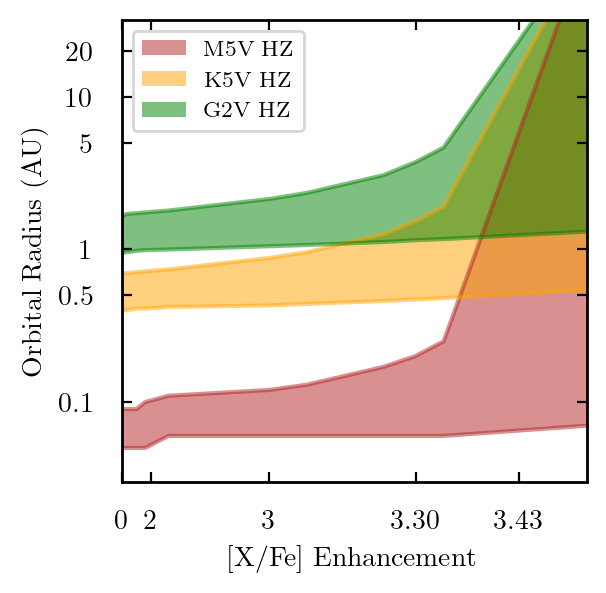

In [53]:

fig, ax = plt.subplots(figsize=(3, 3), dpi=200)
ax.plot(10**limits_enhancements, M5V_inner_limits, color='firebrick', alpha=0.5, linestyle='-')#, label='M5V Inner HZ Limit (1 $M_{\oplus}$)')
ax.plot(10**limits_enhancements, M5V_outer_limits, color='firebrick', alpha=0.5, linestyle='-')#, label='M5V Outer HZ Limit (1 $M_{\oplus}$)')
ax.fill_between(x=10**limits_enhancements, y1=M5V_inner_limits, y2=M5V_outer_limits, color='firebrick', alpha=0.50, edgecolor='None', label='M5V HZ')

ax.plot(10**limits_enhancements, K5V_inner_limits, color='orange', alpha=0.5, linestyle='-')#, label='K5V Inner HZ Limit (1 $M_{\oplus}$)')
ax.plot(10**limits_enhancements, K5V_outer_limits, color='orange', alpha=0.5, linestyle='-')#, label='K5V Outer HZ Limit (1 $M_{\oplus}$)')
ax.fill_between(x=10**limits_enhancements, y1=K5V_inner_limits, y2=K5V_outer_limits, color='orange', alpha=0.50, edgecolor='None', label='K5V HZ')

ax.plot(10**limits_enhancements, G2V_inner_limits, color='green', alpha=0.5, linestyle='-')#, label='G2V Inner HZ Limit (1 $M_{\oplus}$)')
ax.plot(10**limits_enhancements, G2V_outer_limits, color='green', alpha=0.5, linestyle='-')#, label='G2V Outer HZ Limit (1 $M_{\oplus}$
ax.fill_between(x=10**limits_enhancements, y1=G2V_inner_limits, y2=G2V_outer_limits, color='green', alpha=0.50, edgecolor='None', label='G2V HZ')

ax.set_ylim(3e-2,32)
ax.set_yscale('log')
ax.set_yticks([0.1, 0.5, 1, 5, 10, 20])
ax.set_yticklabels(['0.1', '0.5', '1', '5', '10', '20'])
# turn off minor y ticks
ax.yaxis.set_minor_locator(plt.NullLocator())

ax.set_xlim(0, 10**limits_enhancements[-1])
ax.set_xticks([1, 200, 1000, 2000, 2700])
ax.set_xticklabels(['0', '2', '3', '3.30', '3.43'])

ax.legend(loc='upper left', fontsize=8)

ax.set_xlabel('[X/Fe] Enhancement')
ax.set_ylabel('Orbital Radius (AU)')

Text(0, 0.5, '[X/Fe] Enhancement')

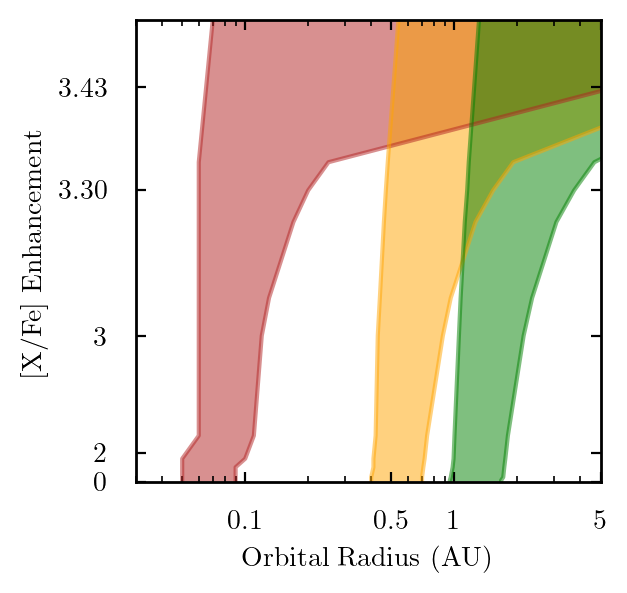

In [54]:

fig, ax = plt.subplots(figsize=(3, 3), dpi=200)

# switch the x and y axes
ax.plot(M5V_inner_limits, 10**limits_enhancements, color='firebrick', alpha=0.5, linestyle='-')#, label='M5V Inner HZ Limit (1 $M_{\oplus}$)')
ax.plot(M5V_outer_limits, 10**limits_enhancements, color='firebrick', alpha=0.5, linestyle='-')#, label='M5V Outer HZ Limit (1 $M_{\oplus}$)')
ax.fill_betweenx(y=10**limits_enhancements, x1=M5V_inner_limits, x2=M5V_outer_limits, color='firebrick', alpha=0.50, edgecolor='None')#, label='M5V HZ (1 $M_{\oplus}$)')

ax.plot(K5V_inner_limits, 10**limits_enhancements, color='orange', alpha=0.5, linestyle='-')#, label='K5V Inner HZ Limit (1 $M_{\oplus}$)')
ax.plot(K5V_outer_limits, 10**limits_enhancements, color='orange', alpha=0.5, linestyle='-')#, label='K5V Outer HZ Limit (1 $M_{\oplus}$)')
ax.fill_betweenx(y=10**limits_enhancements, x1=K5V_inner_limits, x2=K5V_outer_limits, color='orange', alpha=0.50, edgecolor='None')#, label='K5V HZ (1 $M_{\oplus}$)')

ax.plot(G2V_inner_limits, 10**limits_enhancements, color='green', alpha=0.5, linestyle='-')#, label='G2V Inner HZ Limit (1 $M_{\oplus}$)')
ax.plot(G2V_outer_limits, 10**limits_enhancements, color='green', alpha=0.5, linestyle='-')#, label='G2V Outer HZ Limit (1 $M_{\oplus}$)')
ax.fill_betweenx(y=10**limits_enhancements, x1=G2V_inner_limits, x2=G2V_outer_limits, color='green', alpha=0.50, edgecolor='None')#, label='G2V HZ (1 $M_{\oplus}$)')

ax.set_xlim(3e-2,5)
ax.set_xscale('log')
ax.set_xticks([0.1, 0.5, 1, 5])
ax.set_xticklabels(['0.1', '0.5', '1', '5'])
# turn off minor y ticks
ax.yaxis.set_minor_locator(plt.NullLocator())

ax.set_ylim(0, 10**limits_enhancements[-1])
ax.set_yticks([1, 200, 1000, 2000, 2700])
ax.set_yticklabels(['0', '2', '3', '3.30', '3.43'])

ax.set_xlabel('Orbital Radius (AU)')
ax.set_ylabel('[X/Fe] Enhancement')

In [55]:
# at what orbital distance would an 8 earth mass planet (with a radius of about 3 R_earth) receive 1500 Wm2? 1000? 500? 300? 200? 100? 50? 10?
import os

target_fluxes = np.linspace(1500, 10, 100000)

file_out = 'G2_flux_distance_mapping.txt'
if file_out in os.listdir():
    os.remove(file_out)
for target in target_fluxes:
    idx = np.argmin(np.abs(G2_stellar_fluxes - target))
    distance = G2_distances_au[idx]
    # write to a file the target flux, distance, and actual stellar flux at that distance
    with open(file_out, 'a') as f:        
        f.write(f"{target:.1f} : {distance:.3f} : {G2_stellar_fluxes[idx]:.1f}\n")

file_out = 'K5_flux_distance_mapping.txt'
if file_out in os.listdir():
    os.remove(file_out)
for target in target_fluxes:
    idx = np.argmin(np.abs(K5_stellar_fluxes - target))
    distance = K5_distances_au[idx]
    # write to a file the target flux, distance, and actual stellar flux at that distance
    with open(file_out, 'a') as f:        
        f.write(f"{target:.1f} : {distance:.3f} : {K5_stellar_fluxes[idx]:.1f}\n")

file_out = 'M5_flux_distance_mapping.txt'
if file_out in os.listdir():
    os.remove(file_out)
for target in target_fluxes:
    idx = np.argmin(np.abs(M5_stellar_fluxes - target))
    distance = M5_distances_au[idx]
    # write to a file the target flux, distance, and actual stellar flux at that distance
    with open(file_out, 'a') as f:        
        f.write(f"{target:.1f} : {distance:.3f} : {M5_stellar_fluxes[idx]:.1f}\n")

In [56]:
# read the file, plot the mapping
tgt_flx, dist, st_flx = np.genfromtxt('M5_flux_distance_mapping.txt', delimiter=':', unpack=True)

In [57]:
# find where stellar flux is equal to some number x
def find_distance_for_flux(x):
    idx = np.argmin(np.abs(st_flx - x))
    return dist[idx], st_flx[idx]

In [58]:
find_distance_for_flux(265*4)

(np.float64(0.06), np.float64(1147.3))

In [59]:
# what flux would a planet at 1 AU recieved from a G2V star? at 2 AU? at 5 AU?
distances_to_check = [1.0, 1.2, 1.5, 2.0, 5.0]
for dist in distances_to_check:
    idx = np.argmin(np.abs(G2_distances_au - dist))
    flux = G2_stellar_fluxes[idx] / (np.pi * 4)  # convert from total to per unit area
    print(f"At {dist:.1f} AU, stellar flux is approximately {flux:.1f} W/m²")

At 1.0 AU, stellar flux is approximately 110.8 W/m²
At 1.2 AU, stellar flux is approximately 76.9 W/m²
At 1.5 AU, stellar flux is approximately 49.2 W/m²
At 2.0 AU, stellar flux is approximately 27.7 W/m²
At 5.0 AU, stellar flux is approximately 4.4 W/m²
